In [1]:
# Micro correlation
.libPaths()
library(Signac)
library(Seurat)
library(dplyr)
library(ggplot2)
library(data.table)
library(rtracklayer)
library(stringr)
library(cowplot)
library(patchwork)
library(tidyverse)
library(ggpubr)
library(dplyr)
library(stringr)
library(ggplot2)
library(ggpubr)

[1] "/cwStorage/home/yzhang/new_envs/my_env/lib/R/library"

载入需要的程序包：SeuratObject

载入需要的程序包：sp


载入程序包：‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



载入程序包：‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



载入程序包：‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


载入需要的程序包：GenomicRanges

载入需要的程序包：stats4

载入需要的程序包：BiocGenerics


载入程序包：‘BiocGenerics’


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following object is masked from ‘package:SeuratObject’:

    intersect


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect,

In [168]:
tmp=read.csv('/cwStorage/nodecw_group/czh_data/Glasnost/mm/RSS/RSS-single-major_brain_major.csv')
rownames(tmp)=tmp$X
tmp$X=NULL
tmp=as.data.frame(t(tmp))


In [169]:
tmp

,sub | Oli,pal | Oli,sub | Immune,pal | Immune,sub | OPC,pal | OPC,sub | Ast-ep,pal | Ast-ep
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Ahctf1,0.4850125,0.4753944,0.3854777,0.5775139,0.5560649,0.3854249,0.5943518,0.3597648
Ar,0.5317319,0.5210112,0.4136435,0.6300784,0.6786332,0.3869071,0.7063039,0.3581228
Arntl,0.5247435,0.5042671,0.4092644,0.6170762,0.6586843,0.3755118,0.6458370,0.3548946
Atf6,0.5355496,0.5155919,0.4060812,0.6330036,0.6762688,0.3835760,0.6972821,0.3537654
Bach2,0.5181585,0.4989368,0.4098572,0.6204002,0.6827217,0.3801824,0.7009004,0.3609226
Cebpa,0.3482080,0.3395080,0.4260010,0.6272994,0.3471455,0.3024689,0.3701505,0.2775606
Chd2,0.5385316,0.5260203,0.4144598,0.6533182,0.6740644,0.3926152,0.6981133,0.3683903
Ctnnb1,0.5305569,0.5085923,0.3996953,0.5921369,0.6693459,0.3762993,0.6728528,0.3586548
Cux2,0.4539336,0.4485216,0.3880324,0.5622615,0.5460907,0.3646646,0.5488241,0.3179276


In [182]:
rownames(tmp)[order(tmp$`sub | Ast-ep`)][1:20]
rownames(tmp)[order(tmp$`pal | Ast-ep`)][1:20]

[1] "Egr3"   "Fos"    "E2f4"   "Meis3"  "Deaf1"  "Elk3"   "Junb"   "Cebpa" 
 [9] "Eomes"  "Pgr"    "Tal1"   "Klf5"   "Pou6f1" "Runx1"  "Sox6"   "Nfe2l2"
[17] "Ebf1"   "Runx2"  "Nkx2.1" "Zfp57"

[1] "Egr3"   "Fos"    "Meis3"  "E2f4"   "Elk3"   "Junb"   "Deaf1"  "Cebpa" 
 [9] "Klf5"   "Eomes"  "Pou6f1" "Runx1"  "Ebf1"   "Pgr"    "Zfp57"  "Tal1"  
[17] "Sox6"   "Cux2"   "Sp4"    "Isl1"

In [179]:
length(intersect(rownames(tmp)[order(tmp$`pal | OPC`)][1:20],rownames(tmp)[order(tmp$`sub | OPC`)][1:20]))

[1] 16

In [2]:
spatial=read.csv('/home1/yzhang/Project_SN_Multiome/Analysis/Spatial_integration/sn_plaqueD_metadata.csv')
# 假设你的数据框叫 df，第一列叫 V1
spatial$Clean_Barcode <- gsub("@.*$", "", spatial$X)

# 解释：
# "@" 匹配字符 @
# ".*" 匹配 @ 后面的任意字符，直到字符串结尾("$")
# "" 表示将其替换为什么都没有（即删除）
head(spatial)

,X,nearest_plaque,min_center_dist,plaque_region,interval,near_plaque,sample_id,region,major_ct,Clean_Barcode
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,HZ2U_pal_AAACCCAATGATTCGCT@0,HZ2M01_others_1,638.1928,others,>100,other,HZ2M01,SS,Glut,HZ2U_pal_AAACCCAATGATTCGCT
2,HZ2U_pal_AAACCCAATGGTAACAC@0,HZ2M01_others_1,838.5732,others,>100,other,HZ2M01,WM,Glut,HZ2U_pal_AAACCCAATGGTAACAC
3,HZ2U_pal_AAACCCACGATCGAGCC@0,HZ2M01_others_1,1639.8918,others,>100,other,HZ2M01,BF,334 Microglia NN,HZ2U_pal_AAACCCACGATCGAGCC
4,HZ2U_pal_AAACCCACGATGACTCA@0,HZ2M01_others_1,2595.3763,others,>100,other,HZ2M01,SS,Glut,HZ2U_pal_AAACCCACGATGACTCA
5,HZ2U_pal_AAACCCAGCTAAGATTG@0,HZ2M01_others_1,828.9656,others,>100,other,HZ2M01,SS,Glut,HZ2U_pal_AAACCCAGCTAAGATTG
6,HZ2U_pal_AAACCCAGCTACGGGTA@0,HZ2M01_others_1,2307.5433,others,>100,other,HZ2M01,SS,Glut,HZ2U_pal_AAACCCAGCTACGGGTA


In [11]:
dim(spatial)

[1] 281706     10

In [41]:
# ===== 读取数据 =====
combined_full <- readRDS('/public/home/yzhang/zy_data/Project_AD_st/Multiome/Raw_data_0423_full/QC_0512/Combine/Combine_RNA_ATAC_anno_rnafromatac_260219.rds')

DefaultAssay(combined_full) <- "RNA_from_ATAC"
combined_full

An object of class Seurat 
431222 features across 131083 samples within 3 assays 
Active assay: RNA_from_ATAC (21821 features, 0 variable features)
 2 layers present: counts, data
 2 other assays present: ATAC, RNA
 5 dimensional reductions calculated: pca, umap.rna, lsi, umap.atac, wnn.umap

In [42]:
DefaultAssay(combined_full) <- "RNA"

In [34]:
combined_full=subset(combined_full,Final_subclass_name=='334 Microglia NN')

In [36]:
combined_full

An object of class Seurat 
431222 features across 14407 samples within 3 assays 
Active assay: RNA (16351 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 2 other assays present: ATAC, RNA_from_ATAC
 5 dimensional reductions calculated: pca, umap.rna, lsi, umap.atac, wnn.umap

In [18]:
library(Seurat)
library(dplyr)
library(ggplot2)
library(tidyr)

In [9]:
# 假设你的距离数据框名为 plaque_df
# 1. 合并元数据
# 请确保 plaque_df 的 'X' 或 'Clean_Barcode' 与 combined 的 rownames 对应
new_meta <- combined_full@meta.data 
new_meta = spatial %>%
  inner_join(new_meta,by =c( "Clean_Barcode"="cell_id")) %>%
  mutate(dist_um = min_center_dist / 2)       # 转换为微米

In [10]:
new_meta

X.x,nearest_plaque,min_center_dist,plaque_region,interval,near_plaque,sample_id,region,major_ct,Clean_Barcode,⋯,nucleosome_percentile,TSS.enrichment,TSS.percentile,blacklist_fraction,nt_type_label,class_id_label,neighborhood,nCount_RNA_from_ATAC,nFeature_RNA_from_ATAC,dist_um
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<int>,<dbl>
HZ2U_pal_AAACCCAATGATTCGCT@0,HZ2M01_others_1,638.1928,others,>100,other,HZ2M01,SS,Glut,HZ2U_pal_AAACCCAATGATTCGCT,⋯,0.43,6.176680,0.47,0.02922384,Glut,01 IT-ET Glut,Pallium-Glut,4970,3464,319.0964
HZ2U_pal_AAACCCAATGGTAACAC@0,HZ2M01_others_1,838.5732,others,>100,other,HZ2M01,WM,Glut,HZ2U_pal_AAACCCAATGGTAACAC,⋯,0.76,3.001443,0.08,0.02312011,Glut,02 NP-CT-L6b Glut,Pallium-Glut,11018,5572,419.2866
HZ2U_pal_AAACCCACGATCGAGCC@0,HZ2M01_others_1,1639.8918,others,>100,other,HZ2M01,BF,334 Microglia NN,HZ2U_pal_AAACCCACGATCGAGCC,⋯,0.10,10.385170,0.89,0.02521359,NA,34 Immune,NN-IMN-GC,2509,2088,819.9459
HZ2U_pal_AAACCCACGATGACTCA@0,HZ2M01_others_1,2595.3763,others,>100,other,HZ2M01,SS,Glut,HZ2U_pal_AAACCCACGATGACTCA,⋯,0.52,8.164058,0.71,0.02617753,Glut,01 IT-ET Glut,Pallium-Glut,5889,4123,1297.6881
HZ2U_pal_AAACCCAGCTAAGATTG@0,HZ2M01_others_1,828.9656,others,>100,other,HZ2M01,SS,Glut,HZ2U_pal_AAACCCAGCTAAGATTG,⋯,0.49,5.840456,0.42,0.02621232,Glut,02 NP-CT-L6b Glut,Pallium-Glut,6105,3842,414.4828
HZ2U_pal_AAACCCAGCTACGGGTA@0,HZ2M01_others_1,2307.5433,others,>100,other,HZ2M01,SS,Glut,HZ2U_pal_AAACCCAGCTACGGGTA,⋯,0.41,3.652192,0.15,0.01420315,Glut,01 IT-ET Glut,Pallium-Glut,9603,5097,1153.7716
HZ2U_pal_AAACCCAGCTAGGACAC@0,HZ2M01_others_1,1491.0416,others,>100,other,HZ2M01,BF,Glut,HZ2U_pal_AAACCCAGCTAGGACAC,⋯,0.40,4.347584,0.24,0.02566398,Glut,16 HY MM Glut,HY-EA-Glut-GABA,13830,6745,745.5208
HZ2U_pal_AAACCCAGCTAGTTACC@0,HZ2M01_others_1,1567.6431,others,>100,other,HZ2M01,BF,GABA,HZ2U_pal_AAACCCAGCTAGTTACC,⋯,0.55,9.822964,0.86,0.03279196,GABA,20 MB GABA,MB-HB-CB-GABA,4028,2965,783.8216
HZ2U_pal_AAACCCAGCTCCAGCCA@0,HZ2M01_others_1,1207.2055,others,>100,other,HZ2M01,OLF,Glut,HZ2U_pal_AAACCCAGCTCCAGCCA,⋯,0.85,6.808576,0.55,0.02547022,Glut,01 IT-ET Glut,Pallium-Glut,3804,2990,603.6027


In [19]:
# 1. 准备基因列表（已转换为小鼠格式）
# 注意：KMT3D 在小鼠中对应的常用名是 Kmt2d
target_genes <- c("Tet2", "Asxl1", "Kmt2d", "Atrx", "Cbl")

# 2. 从 Seurat 对象中提取表达量数据
# FetchData 会返回一个以 cell_id 为行名的 data.frame
expr_data <- FetchData(combined_full, vars = target_genes)
expr_data$brain=combined_full$brain
expr_data$cell_id <- rownames(expr_data)

# 3. 直接在外部进行数据合并与处理
# 假设你的距离数据框是 plaque_df，且 'X' 列对应 cell_id
plot_df <- spatial %>%
  # 转换距离单位为微米
  mutate(dist_um = min_center_dist / 2) %>%
  # 合并表达量（即使 plaque_df 中 X 有重复，join 也会正确处理）
  inner_join(expr_data, by = c("Clean_Barcode" = "cell_id")) %>%
  # 转换为长表格格式以便 ggplot 绘图
  pivot_longer(cols = all_of(target_genes), 
               names_to = "Gene", 
               values_to = "Expression")

`geom_smooth()` using formula = 'y ~ x'


In [24]:
names(plot_df)

[1] "X"               "nearest_plaque"  "min_center_dist" "plaque_region"  
 [5] "interval"        "near_plaque"     "sample_id"       "region"         
 [9] "major_ct"        "Clean_Barcode"   "dist_um"         "brain"          
[13] "Gene"            "Expression"

In [21]:
library(dplyr)
library(ggplot2)
library(stringr)


In [22]:
# 1. 定义分箱参数
bin_size <- 25
breaks_seq <- seq(0, 2000, by = bin_size)

In [25]:
library(dplyr)
library(stringr)

# 2. 对前一步生成的 plot_df 进行分箱和汇总计算
plot_df_binned <- plot_df %>%
  # 过滤掉超出我们最大分箱范围的离群细胞
  filter(dist_um <= max(breaks_seq)) %>%
  mutate(
    # 使用 cut() 将连续距离划分为离散的 bin
    dist_bin = cut(dist_um, breaks = breaks_seq, include.lowest = TRUE, right = FALSE),
    
    # 修复报错：直接提取分箱字符串中的第一个数字（兼容带小数点的数值）
    bin_lower = as.numeric(str_extract(dist_bin, "\\d+\\.?\\d*")),
    
    # 计算中点作为 X 轴坐标
    bin_center = bin_lower + (bin_size / 2)
  )

# 检查一下提取是否正确
head(plot_df_binned %>% select(dist_um, dist_bin, bin_lower, bin_center))

dist_um,dist_bin,bin_lower,bin_center
<dbl>,<fct>,<dbl>,<dbl>
319.0964,"[300,325)",300,312.5
319.0964,"[300,325)",300,312.5
319.0964,"[300,325)",300,312.5
319.0964,"[300,325)",300,312.5
319.0964,"[300,325)",300,312.5
419.2866,"[400,425)",400,412.5


In [31]:
plot_df_binned[(plot_df_binned$bin_center=='13.5'),]

X,nearest_plaque,min_center_dist,plaque_region,interval,near_plaque,sample_id,region,major_ct,Clean_Barcode,dist_um,brain,Gene,Expression,dist_bin,bin_lower,bin_center
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<fct>,<dbl>,<dbl>
HZ2U_pal_AAAGGATATGTGGCCAG@0,HZ2M01_others_1,2016.688,others,>100,other,HZ2M01,,Glut,HZ2U_pal_AAAGGATATGTGGCCAG,1008.344,pal,Tet2,0.0000000,"[1e+03,1.02e+03)",1,13.5
HZ2U_pal_AAAGGATATGTGGCCAG@0,HZ2M01_others_1,2016.688,others,>100,other,HZ2M01,,Glut,HZ2U_pal_AAAGGATATGTGGCCAG,1008.344,pal,Asxl1,0.0000000,"[1e+03,1.02e+03)",1,13.5
HZ2U_pal_AAAGGATATGTGGCCAG@0,HZ2M01_others_1,2016.688,others,>100,other,HZ2M01,,Glut,HZ2U_pal_AAAGGATATGTGGCCAG,1008.344,pal,Kmt2d,0.0000000,"[1e+03,1.02e+03)",1,13.5
HZ2U_pal_AAAGGATATGTGGCCAG@0,HZ2M01_others_1,2016.688,others,>100,other,HZ2M01,,Glut,HZ2U_pal_AAAGGATATGTGGCCAG,1008.344,pal,Atrx,0.0000000,"[1e+03,1.02e+03)",1,13.5
HZ2U_pal_AAAGGATATGTGGCCAG@0,HZ2M01_others_1,2016.688,others,>100,other,HZ2M01,,Glut,HZ2U_pal_AAAGGATATGTGGCCAG,1008.344,pal,Cbl,0.0000000,"[1e+03,1.02e+03)",1,13.5
HZ2U_pal_AACACACATGACGATAC@0,HZ2M01_others_1,2000.952,others,>100,other,HZ2M01,PFC,Glut,HZ2U_pal_AACACACATGACGATAC,1000.476,pal,Tet2,1.5506875,"[1e+03,1.02e+03)",1,13.5
HZ2U_pal_AACACACATGACGATAC@0,HZ2M01_others_1,2000.952,others,>100,other,HZ2M01,PFC,Glut,HZ2U_pal_AACACACATGACGATAC,1000.476,pal,Asxl1,0.0000000,"[1e+03,1.02e+03)",1,13.5
HZ2U_pal_AACACACATGACGATAC@0,HZ2M01_others_1,2000.952,others,>100,other,HZ2M01,PFC,Glut,HZ2U_pal_AACACACATGACGATAC,1000.476,pal,Kmt2d,0.0000000,"[1e+03,1.02e+03)",1,13.5
HZ2U_pal_AACACACATGACGATAC@0,HZ2M01_others_1,2000.952,others,>100,other,HZ2M01,PFC,Glut,HZ2U_pal_AACACACATGACGATAC,1000.476,pal,Atrx,1.5506875,"[1e+03,1.02e+03)",1,13.5


In [26]:
# 3. 按脑区、基因和距离 Bin 计算均值和标准误 (SE)
df_summary <- plot_df_binned %>%
  group_by(brain, Gene, bin_center) %>%
  summarise(
    mean_expr = mean(Expression, na.rm = TRUE),
    # 可选：计算标准误，用于画误差棒 (SD / sqrt(N))
    se_expr = sd(Expression, na.rm = TRUE) / sqrt(n()),
    # 记录该 bin 里的细胞数量
    cell_count = n(), 
    .groups = "drop"
  ) %>%
  # 可选：过滤掉细胞数量太少的 bin（例如少于 5 个细胞），防止均值波动太大
  filter(cell_count >= 5)

In [27]:
df_summary

brain,Gene,bin_center,mean_expr,se_expr,cell_count
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>
pal,Asxl1,12.50,0.2790526,0.01293337,2274
pal,Asxl1,13.50,0.2694014,0.01475747,1219
pal,Asxl1,13.52,0.2944721,0.01639339,1135
pal,Asxl1,13.55,0.3112920,0.01669600,1123
pal,Asxl1,13.58,0.3019595,0.01694270,1135
pal,Asxl1,13.60,0.3199697,0.01869832,992
pal,Asxl1,13.62,0.2793126,0.01771481,936
pal,Asxl1,13.65,0.2981772,0.01753293,962
pal,Asxl1,13.68,0.3071812,0.01821075,899


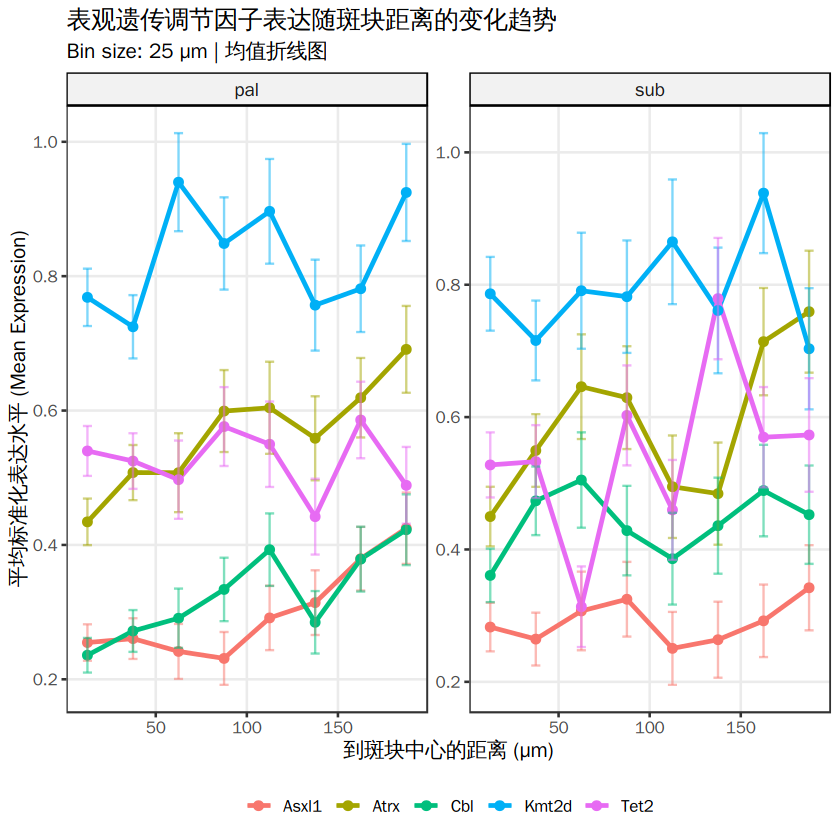

In [38]:
library(dplyr)
library(tidyr)
library(ggplot2)

# ==========================================
# 1. 提取表达量数据
# ==========================================
target_genes <- c("Tet2", "Asxl1", "Kmt2d", "Atrx", "Cbl")

# 从 Seurat 对象提取数据并添加脑区和细胞ID
expr_data <- FetchData(combined_full, vars = target_genes)
expr_data$brain <- combined_full$brain
expr_data$cell_id <- rownames(expr_data)

# ==========================================
# 2. 空间分箱、合并与汇总 (一步到位链式操作)
# ==========================================
bin_size <- 25

df_binned_genes <- spatial %>%
  # 换算物理距离 (um)
  mutate(dist_um = min_center_dist / 2) %>%
  # 过滤掉超出 2000um 的细胞 (根据你需要分析的最大距离而定)
  filter(dist_um <= 200) %>%
  # 与表达量数据合并
  inner_join(expr_data, by = c("Clean_Barcode" = "cell_id")) %>%
  
  # ✨ 核心极简替换：用 floor() 一步直接计算出所在的箱体中心坐标！
  mutate(
    bin_center = floor(dist_um / bin_size) * bin_size + (bin_size / 2)
  ) %>%
  
  # 转换为长表格，把 5 个基因压缩成 Gene 和 Expression 两列，方便画图
  pivot_longer(
    cols = all_of(target_genes),
    names_to = "Gene",
    values_to = "Expression"
  ) %>%
  
  # 按【箱体中心】、【脑区】和【基因】分组计算均值
  group_by(bin_center, brain, Gene) %>%
  summarise(
    Mean_Expr = mean(Expression, na.rm = TRUE),
    SE_Expr = sd(Expression, na.rm = TRUE) / sqrt(n()),
    # 因为拉长了数据，这里的 n() 代表该基因在该 bin 中的细胞数
    Count = n(), 
    .groups = "drop"
  ) %>%
  
  # 过滤掉细胞数太少的箱子，防止极端噪点（例如距斑块极近或极远的地方细胞太少）
  filter(Count >= 3) 

# ==========================================
# 3. 绘制多基因空间梯度折线图
# ==========================================
p_genes_spatial <- ggplot(df_binned_genes, aes(x = bin_center, y = Mean_Expr, color = Gene)) +
  # 添加趋势折线和均值散点
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  
  # (可选) 添加误差棒展现数据分布，如果觉得多基因导致画面太乱，可以加 # 注释掉这行
  geom_errorbar(aes(ymin = Mean_Expr - SE_Expr, ymax = Mean_Expr + SE_Expr), 
                width = 5, alpha = 0.5) +
  
  # 按脑区分面显示 (不同脑区单独的图表)
  facet_wrap(~ brain, scales = "free_y") +
  
  theme_bw(base_size = 12) +
  labs(
    title = "表观遗传调节因子表达随斑块距离的变化趋势",
    subtitle = paste0("Bin size: ", bin_size, " µm | 均值折线图"),
    x = "到斑块中心的距离 (µm)",
    y = "平均标准化表达水平 (Mean Expression)"
  ) +
  theme(
    strip.background = element_rect(fill = "#f2f2f2", color = "black"),
    strip.text = element_text(face = "bold", size = 11),
    legend.position = "bottom",
    legend.title = element_blank(),
    panel.grid.minor = element_blank() # 去除小网格线让画面更干净
  )

# 打印图表
print(p_genes_spatial)

# 保存图片 (按需解开注释)
# ggsave("Epigenetic_Genes_Spatial_Gradient.pdf", p_genes_spatial, width = 10, height = 6)

# spatial GRN

In [49]:
library(dplyr)

# 1. 读入数据，强制 R 语言保留原始列名（不将特殊符号变成点号）
AUC_gene <- read.csv('/home1/yzhang/Project_SN_Multiome/Analysis/Scenic+/Version_2_mouse/gene_AUC_matrix.csv', check.names = FALSE)

# 2. 识别并过滤列
# 第一列通常是细胞ID，我们先把它单独拿出来（假设列名叫 "Cell" 或 第一列）
cell_col_name <- colnames(AUC_gene)[1]

# 获取所有列名
all_cols <- colnames(AUC_gene)

# 使用 grep 匹配包含 "+/+" 的列
# 注意：在正则表达式中 "+" 是特殊字符，需要用 "\\+" 进行转义
plus_plus_cols <- all_cols[grepl("\\+/\\+", all_cols)]

# 将 细胞ID列 和 带有 "+/+" 的列合并，完成过滤
AUC_gene <- AUC_gene[, c(cell_col_name, plus_plus_cols)]

# 3. 检查过滤后的列名是否正确
print(paste("过滤后剩余列数:", ncol(AUC_gene)))
head(colnames(AUC_gene))

fix_cell_ids <- function(ids) {
  # 正则表达式解释：
  # ^([^-]+) : 匹配开头到第一个 "-" 之间的所有字符（即 Barcode），记为组1
  # -        : 匹配中间的 "-"
  # (.*)$    : 匹配 "-" 后面的所有字符（即 Sample），记为组2
  # \\2_\\1  : 替换为 "组2_组1"
  gsub("^([^-]+)-(.*)$", "\\2_\\1", ids)
}

AUC_gene[[cell_col_name]] <- fix_cell_ids(AUC_gene[[cell_col_name]])

[1] "过滤后剩余列数: 104"


[1] "Cell"                    "Ahctf1_direct_+/+_(39g)"
[3] "Ar_direct_+/+_(179g)"    "Arntl_direct_+/+_(37g)" 
[5] "Atf6_direct_+/+_(86g)"   "Bach2_direct_+/+_(89g)"

In [50]:
head(AUC_gene)

,Cell,Ahctf1_direct_+/+_(39g),Ar_direct_+/+_(179g),Arntl_direct_+/+_(37g),Atf6_direct_+/+_(86g),Bach2_direct_+/+_(89g),Cebpa_direct_+/+_(24g),Chd2_direct_+/+_(388g),Ctnnb1_direct_+/+_(54g),Cux2_direct_+/+_(17g),⋯,Tcf4_direct_+/+_(991g),Tcf7l2_direct_+/+_(175g),Tef_direct_+/+_(140g),Thra_direct_+/+_(285g),Thrb_direct_+/+_(566g),Zbtb16_direct_+/+_(32g),Zeb1_direct_+/+_(402g),Zfp148_direct_+/+_(856g),Zfp57_direct_+/+_(15g),Zfp740_direct_+/+_(22g)
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,HZ6U_pal_CTCTCGATACAGTCGAC,0.02159739,0.15475816,0.10731514,0.1986553,0.04624873,0.00000000,0.02796927,0.01537173,0.05832015,⋯,0.11229550,0.04823612,0.07757597,0.08744477,0.15379016,0.206945293,0.07734859,0.11355340,0.00000000,0.02083796
2,WT3U_sub_TTTGTTGGCTAGGTCAG,0.03642405,0.10081818,0.11828454,0.2022517,0.14200159,0.00000000,0.03449134,0.01566603,0.10779520,⋯,0.13992312,0.04656654,0.05601642,0.10459400,0.15507745,0.176382946,0.10874418,0.11377619,0.02901385,0.02467215
3,HZ3U_pal_GGAATCTTACGGTCGGT,0.03413579,0.11714770,0.12664376,0.1946182,0.13746875,0.01747148,0.05163461,0.01713755,0.15173306,⋯,0.13398336,0.04923507,0.08526022,0.11565221,0.17861370,0.163852384,0.10536559,0.11416465,0.09828851,0.05395643
4,HZ2U_sub_TGTTTGTGCTACAGTCT,0.01608050,0.13009657,0.15023459,0.2800222,0.04249883,0.00000000,0.05090994,0.02252558,0.16165684,⋯,0.07078499,0.03414600,0.15911631,0.10329859,0.12798820,0.037706296,0.13514944,0.09883349,0.03545232,0.05401200
5,HZ2U_pal_ACAACCATACCCGATCC,0.03880634,0.02315226,0.05788674,0.0708620,0.01129090,0.18210065,0.06462204,0.05034864,0.07011362,⋯,0.03046489,0.04991966,0.02903423,0.03613006,0.04545474,0.003285452,0.06245362,0.06557623,0.01809291,0.03978662
6,HZ3U_sub_AGTCTCCGCTGGCTGAA,0.01253840,0.17417465,0.16596181,0.3530449,0.06014945,0.00000000,0.02896806,0.03850856,0.10189846,⋯,0.14144045,0.04725114,0.12202235,0.15684382,0.20350851,0.235024450,0.10059118,0.14339882,0.04009780,0.06090242


In [40]:
spatial=read.csv('/home1/yzhang/Project_SN_Multiome/Analysis/Spatial_integration/sn_plaqueD_metadata.csv')
# 假设你的数据框叫 df，第一列叫 V1
spatial$Clean_Barcode <- gsub("@.*$", "", spatial$X)

# 解释：
# "@" 匹配字符 @
# ".*" 匹配 @ 后面的任意字符，直到字符串结尾("$")
# "" 表示将其替换为什么都没有（即删除）
head(spatial)

,X,nearest_plaque,min_center_dist,plaque_region,interval,near_plaque,sample_id,region,major_ct,Clean_Barcode
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,HZ2U_pal_AAACCCAATGATTCGCT@0,HZ2M01_others_1,638.1928,others,>100,other,HZ2M01,SS,Glut,HZ2U_pal_AAACCCAATGATTCGCT
2,HZ2U_pal_AAACCCAATGGTAACAC@0,HZ2M01_others_1,838.5732,others,>100,other,HZ2M01,WM,Glut,HZ2U_pal_AAACCCAATGGTAACAC
3,HZ2U_pal_AAACCCACGATCGAGCC@0,HZ2M01_others_1,1639.8918,others,>100,other,HZ2M01,BF,334 Microglia NN,HZ2U_pal_AAACCCACGATCGAGCC
4,HZ2U_pal_AAACCCACGATGACTCA@0,HZ2M01_others_1,2595.3763,others,>100,other,HZ2M01,SS,Glut,HZ2U_pal_AAACCCACGATGACTCA
5,HZ2U_pal_AAACCCAGCTAAGATTG@0,HZ2M01_others_1,828.9656,others,>100,other,HZ2M01,SS,Glut,HZ2U_pal_AAACCCAGCTAAGATTG
6,HZ2U_pal_AAACCCAGCTACGGGTA@0,HZ2M01_others_1,2307.5433,others,>100,other,HZ2M01,SS,Glut,HZ2U_pal_AAACCCAGCTACGGGTA


In [ ]:
# ===== 读取数据 =====
combined_full <- readRDS('/public/home/yzhang/zy_data/Project_AD_st/Multiome/Raw_data_0423_full/QC_0512/Combine/Combine_RNA_ATAC_anno_rnafromatac_260219.rds')

DefaultAssay(combined_full) <- "RNA"
combined_full

In [52]:
meta=combined_full@meta.data %>%
  select('genotype','month','brain','cell_id','class_id_label')

In [46]:
spatial=spatial%>%
  select('X','min_center_dist','sample_id','Clean_Barcode')%>%
  mutate(num_dist=min_center_dist/2)

In [54]:
spatial=spatial%>%
  inner_join(AUC_gene,by = c("Clean_Barcode" = "Cell"))%>%
  inner_join(meta,by = c("Clean_Barcode" = "cell_id"))
dim(spatial)
head(spatial)

[1] 281626    112

,X,min_center_dist,sample_id,Clean_Barcode,num_dist,Ahctf1_direct_+/+_(39g),Ar_direct_+/+_(179g),Arntl_direct_+/+_(37g),Atf6_direct_+/+_(86g),Bach2_direct_+/+_(89g),⋯,Thrb_direct_+/+_(566g),Zbtb16_direct_+/+_(32g),Zeb1_direct_+/+_(402g),Zfp148_direct_+/+_(856g),Zfp57_direct_+/+_(15g),Zfp740_direct_+/+_(22g),genotype,month,brain,class_id_label
,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>
1,HZ2U_pal_AAACCCAATGATTCGCT@0,638.1928,HZ2M01,HZ2U_pal_AAACCCAATGATTCGCT,319.0964,0.027490439,0.159689118,0.16873720,0.25288565,0.06657784,⋯,0.18131787,0.18341229,0.08965259,0.1372906,0.017277914,0.06056902,AD,2,pal,01 IT-ET Glut
2,HZ2U_pal_AAACCCAATGGTAACAC@0,838.5732,HZ2M01,HZ2U_pal_AAACCCAATGGTAACAC,419.2866,0.021816814,0.152961987,0.19146898,0.29875761,0.04608390,⋯,0.17611688,0.24377292,0.09926225,0.1328205,0.038386308,0.08312958,AD,2,pal,02 NP-CT-L6b Glut
3,HZ2U_pal_AAACCCACGATCGAGCC@0,1639.8918,HZ2M01,HZ2U_pal_AAACCCACGATCGAGCC,819.9459,0.016174535,0.008127194,0.06446177,0.02840166,0.04887228,⋯,0.04200325,0.04229065,0.06023671,0.0610947,0.001059495,0.02889531,AD,2,pal,34 Immune
4,HZ2U_pal_AAACCCACGATGACTCA@0,2595.3763,HZ2M01,HZ2U_pal_AAACCCACGATGACTCA,1297.6881,0.005704971,0.157735859,0.11147823,0.23705009,0.06858328,⋯,0.14564308,0.16293551,0.07365070,0.1229520,0.000000000,0.06279173,AD,2,pal,01 IT-ET Glut
5,HZ2U_pal_AAACCCAGCTAAGATTG@0,828.9656,HZ2M01,HZ2U_pal_AAACCCAGCTAAGATTG,414.4828,0.007115541,0.139207223,0.17121523,0.18310400,0.04781462,⋯,0.13905112,0.14455990,0.08010984,0.1008100,0.000000000,0.04689931,AD,2,pal,02 NP-CT-L6b Glut
6,HZ2U_pal_AAACCCAGCTACGGGTA@0,2307.5433,HZ2M01,HZ2U_pal_AAACCCAGCTACGGGTA,1153.7716,0.021252586,0.159941812,0.12647856,0.24124353,0.05865223,⋯,0.16933916,0.18627751,0.08861560,0.1250000,0.000000000,0.04234274,AD,2,pal,01 IT-ET Glut


In [55]:
names(spatial)

[1] "X"                         "min_center_dist"          
  [3] "sample_id"                 "Clean_Barcode"            
  [5] "num_dist"                  "Ahctf1_direct_+/+_(39g)"  
  [7] "Ar_direct_+/+_(179g)"      "Arntl_direct_+/+_(37g)"   
  [9] "Atf6_direct_+/+_(86g)"     "Bach2_direct_+/+_(89g)"   
 [11] "Cebpa_direct_+/+_(24g)"    "Chd2_direct_+/+_(388g)"   
 [13] "Ctnnb1_direct_+/+_(54g)"   "Cux2_direct_+/+_(17g)"    
 [15] "Dbp_direct_+/+_(62g)"      "Deaf1_direct_+/+_(10g)"   
 [17] "Dlx1_direct_+/+_(44g)"     "E2f3_direct_+/+_(25g)"    
 [19] "E2f4_direct_+/+_(10g)"     "Ebf1_direct_+/+_(12g)"    
 [21] "Egr1_direct_+/+_(71g)"     "Egr3_direct_+/+_(10g)"    
 [23] "Elf1_direct_+/+_(217g)"    "Elf4_direct_+/+_(182g)"   
 [25] "Elk3_direct_+/+_(14g)"     "Eomes_direct_+/+_(15g)"   
 [27] "Esrrg_direct_+/+_(336g)"   "Ets1_direct_+/+_(235g)"   
 [29] "Etv5_direct_+/+_(20g)"     "Etv6_direct_+/+_(129g)"   
 [31] "Fli1_direct_+/+_(319g)"    "Fos_direct_+/+_(10g)"     
 [33] "Foxo1_direct_+/+_(20g)"    "Foxp1_direct_+/+_(116g)"  
 [35] "Hlf_direct_+/+_(262g)"     "Irf5_direct_+/+_(147g)"   
 [37] "Irf8_direct_+/+_(312g)"    "Isl1_direct_+/+_(45g)"    
 [39] "Jdp2_direct_+/+_(140g)"    "Junb_direct_+/+_(26g)"    
 [41] "Klf12_direct_+/+_(1393g)"  "Klf13_direct_+/+_(78g)"   
 [43] "Klf3_direct_+/+_(31g)"     "Klf5_direct_+/+_(28g)"    
 [45] "Klf7_direct_+/+_(456g)"    "Lef1_direct_+/+_(154g)"   
 [47] "Lhx6_direct_+/+_(248g)"    "Lhx8_direct_+/+_(142g)"   
 [49] "Maf_direct_+/+_(102g)"     "Mafb_direct_+/+_(18g)"    
 [51] "Mef2c_direct_+/+_(703g)"   "Mef2d_direct_+/+_(49g)"   
 [53] "Meis2_direct_+/+_(546g)"   "Meis3_direct_+/+_(10g)"   
 [55] "Mga_direct_+/+_(387g)"     "Mitf_direct_+/+_(20g)"    
 [57] "Myef2_direct_+/+_(1841g)"  "Neurod2_direct_+/+_(189g)"
 [59] "Nfat5_direct_+/+_(30g)"    "Nfe2l1_direct_+/+_(233g)" 
 [61] "Nfe2l2_direct_+/+_(13g)"   "Nfia_direct_+/+_(399g)"   
 [63] "Nfib_direct_+/+_(690g)"    "Nfix_direct_+/+_(309g)"   
 [65] "Nkx2-1_direct_+/+_(18g)"   "Npas2_direct_+/+_(17g)"   
 [67] "Nr1d1_direct_+/+_(41g)"    "Nr2c2_direct_+/+_(42g)"   
 [69] "Nr3c1_direct_+/+_(203g)"   "Olig2_direct_+/+_(32g)"   
 [71] "Pbx1_direct_+/+_(1378g)"   "Pgr_direct_+/+_(14g)"     
 [73] "Phf21a_direct_+/+_(65g)"   "Pknox2_direct_+/+_(480g)" 
 [75] "Pou6f1_direct_+/+_(12g)"   "Pparg_direct_+/+_(110g)"  
 [77] "Prdm5_direct_+/+_(12g)"    "Prrx1_direct_+/+_(20g)"   
 [79] "Rarb_direct_+/+_(70g)"     "Rfx1_direct_+/+_(1820g)"  
 [81] "Rfx3_direct_+/+_(1167g)"   "Rfx7_direct_+/+_(533g)"   
 [83] "Rora_direct_+/+_(1148g)"   "Runx1_direct_+/+_(17g)"   
 [85] "Runx2_direct_+/+_(11g)"    "Rxrg_direct_+/+_(91g)"    
 [87] "Smad3_direct_+/+_(250g)"   "Sox10_direct_+/+_(148g)"  
 [89] "Sox1_direct_+/+_(26g)"     "Sox5_direct_+/+_(133g)"   
 [91] "Sox6_direct_+/+_(27g)"     "Sox8_direct_+/+_(137g)"   
 [93] "Sp3_direct_+/+_(14g)"      "Sp4_direct_+/+_(24g)"     
 [95] "Sp7_direct_+/+_(28g)"      "Spi1_direct_+/+_(313g)"   
 [97] "Tal1_direct_+/+_(35g)"     "Tbr1_direct_+/+_(250g)"   
 [99] "Tcf4_direct_+/+_(991g)"    "Tcf7l2_direct_+/+_(175g)" 
[101] "Tef_direct_+/+_(140g)"     "Thra_direct_+/+_(285g)"   
[103] "Thrb_direct_+/+_(566g)"    "Zbtb16_direct_+/+_(32g)"  
[105] "Zeb1_direct_+/+_(402g)"    "Zfp148_direct_+/+_(856g)" 
[107] "Zfp57_direct_+/+_(15g)"    "Zfp740_direct_+/+_(22g)"  
[109] "genotype"                  "month"                    
[111] "brain"                     "class_id_label"

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.”


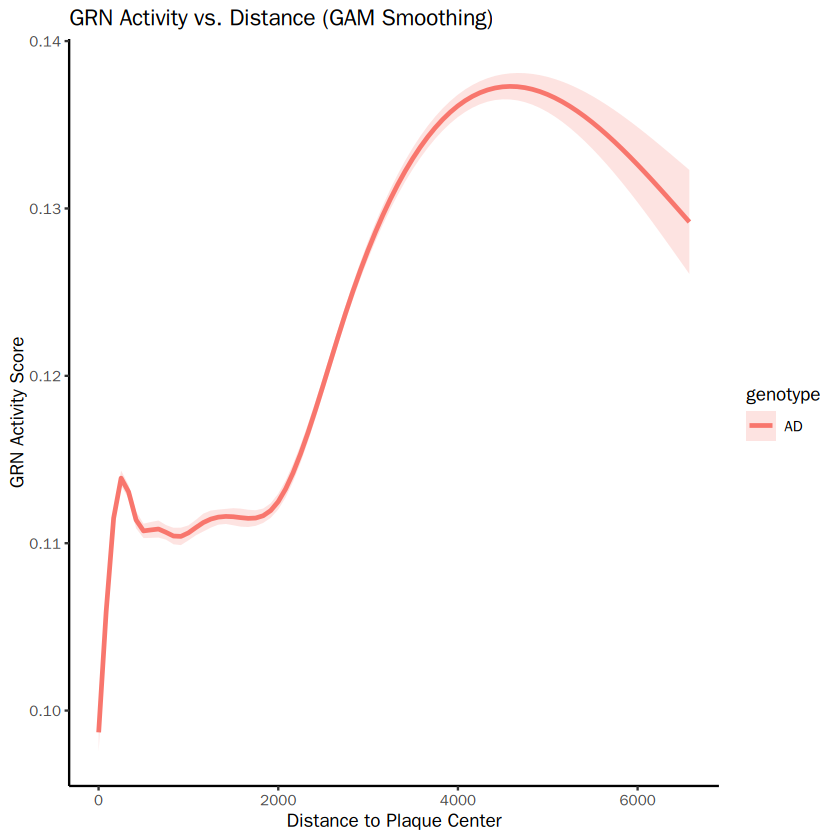

In [57]:
library(ggplot2)
library(mgcv) # GAM 模型需要这个包

target_grn <- "`Mef2c_direct_+/+_(703g)`"

plot_gam <- ggplot(spatial, aes_string(x = "min_center_dist", y = target_grn, color = "genotype", fill = "genotype")) +
  # 使用 gam 替代 loess，bs="cs" 表示使用收缩平滑样条
  geom_smooth(method = "gam", formula = y ~ s(x, bs = "cs"), se = TRUE, alpha = 0.2) + 
  theme_classic() +
  labs(
    title = "GRN Activity vs. Distance (GAM Smoothing)",
    x = "Distance to Plaque Center",
    y = "GRN Activity Score"
  )

print(plot_gam)

## 线性回归

1. 在侧面标注beta和P值
2. 分脑区进行差异分析？
3. TF本身变化+GRN差异结果在图上的标注
4. 用major cell; 很多class id没有结果; OPC和olig分开

In [58]:
library(dplyr)
library(stats)

In [124]:
print("读取差异分析结果...")
DGRN <- read.csv('/home1/yzhang/Project_SN_Multiome/Analysis/Scenic+/Version_2_mouse/Differential_GRN_0515.csv')
sig_diff_grn <- DGRN %>%
  filter(p_val_adj < 0.05 & abs(log2FC) > 0.1)
print(paste("共有", nrow(sig_diff_grn), "个 CellType-GRN 组合通过了差异分析显著性筛选。"))

print("读取 RSS 矩阵...")
RSS <- read.csv('/home1/yzhang/Project_SN_Multiome/Analysis/Scenic+/Version_2_mouse/RSS/RSS_class_id_label.csv', row.names = 1)
RSS <- as.data.frame(t(RSS))

[1] "读取差异分析结果..."
[1] "共有 664 个 CellType-GRN 组合通过了差异分析显著性筛选。"
[1] "读取 RSS 矩阵..."


In [125]:
spatial_sub <- spatial %>% filter(min_center_dist < 200)

# 提取 spatial 数据框中所有复杂的 GRN 列名
grn_cols_spatial <- grep("\\+/\\+", colnames(spatial_sub), value = TRUE)

# 【核心功能】：构建纯 TF 名字到复杂名字的映射字典
# 截取纯 TF 名字 (例如把 "Ahctf1_direct_+/+_(39g)" 变成 "Ahctf1")
pure_tfs_in_spatial <- gsub("_direct_\\+/\\+.*$", "", grn_cols_spatial)
# 创建 named vector 字典，pure_to_complex["Ahctf1"] 将返回 "Ahctf1_direct_+/+_(39g)"
pure_to_complex <- setNames(grn_cols_spatial, pure_tfs_in_spatial)

# 获取所有的细胞类型和月龄
cell_types <- unique(na.omit(spatial_sub$class_id_label))
months <- unique(na.omit(spatial_sub$month))

In [128]:
# ==========================================
# 2. 预计算：为每种细胞类型生成 DGRN 与 RSS Top20 的并集列表
# ==========================================
print("为每种细胞类型计算 DGRN 和 RSS Top20 的并集...")
valid_grns_by_ctype <- list()

for (ctype in cell_types) {
  
  # a. 获取该细胞类型中显著差异的 GRN
  # 假设 sig_diff_grn 中的 Regulon 列已经是类似于 Ahctf1_direct_+/+_(39g) 的复杂名字
  diff_grns <- sig_diff_grn %>%
    filter(CellType == ctype) %>%
    pull(Regulon) %>%
    unique()
  
  # 如果 sig_diff_grn 里的名字恰好是纯 TF，也可以借助字典转换它 (以防万一)
  if (length(diff_grns) > 0 && !any(grepl("\\+/\\+", diff_grns))) {
    diff_grns <- unname(pure_to_complex[diff_grns])
    diff_grns <- na.omit(diff_grns)
  }
  
  # b. 获取该细胞类型中 RSS Top 20 的 GRN (纯 TF 名字)
  if (ctype %in% colnames(RSS)) {
    # 按照当前细胞类型的 RSS 得分降序排列，取前 20 个行名
    top20_pure_tfs <- rownames(RSS)[order(RSS[[ctype]], decreasing = TRUE)[1:20]]
    
    # 使用字典，将这 20 个纯 TF 映射为空间数据中的复杂列名
    top20_complex_grns <- unname(pure_to_complex[top20_pure_tfs])
    top20_complex_grns <- na.omit(top20_complex_grns) # 剔除空间数据中不存在的 TF
  } else {
    top20_complex_grns <- character(0)
    message(paste("警告:", ctype, "不存在于 RSS 矩阵列名中。"))
  }
  
  # c. 取两者并集
  combined_grns <- unique(c(diff_grns, top20_complex_grns))
  
  # 确保选出的这些 GRN 都真实存在于 spatial_sub 的列名中
  combined_grns <- intersect(combined_grns, colnames(spatial_sub))
  
  valid_grns_by_ctype[[ctype]] <- combined_grns
}

[1] "为每种细胞类型计算 DGRN 和 RSS Top20 的并集..."


In [129]:
valid_grns_by_ctype

$`34 Immune`
 [1] "E2f4_direct_+/+_(10g)"   "Fos_direct_+/+_(10g)"   
 [3] "Junb_direct_+/+_(26g)"   "Klf5_direct_+/+_(28g)"  
 [5] "Ebf1_direct_+/+_(12g)"   "Prdm5_direct_+/+_(12g)" 
 [7] "Zfp57_direct_+/+_(15g)"  "Elk3_direct_+/+_(14g)"  
 [9] "Chd2_direct_+/+_(388g)"  "Cux2_direct_+/+_(17g)"  
[11] "E2f3_direct_+/+_(25g)"   "Elf1_direct_+/+_(217g)" 
[13] "Elf4_direct_+/+_(182g)"  "Ets1_direct_+/+_(235g)" 
[15] "Etv5_direct_+/+_(20g)"   "Etv6_direct_+/+_(129g)" 
[17] "Fli1_direct_+/+_(319g)"  "Irf5_direct_+/+_(147g)" 
[19] "Irf8_direct_+/+_(312g)"  "Klf3_direct_+/+_(31g)"  
[21] "Mafb_direct_+/+_(18g)"   "Mitf_direct_+/+_(20g)"  
[23] "Nfe2l2_direct_+/+_(13g)" "Pgr_direct_+/+_(14g)"   
[25] "Runx1_direct_+/+_(17g)"  "Sox6_direct_+/+_(27g)"  
[27] "Spi1_direct_+/+_(313g)"  "Tal1_direct_+/+_(35g)"  
[29] "Cebpa_direct_+/+_(24g)"  "Maf_direct_+/+_(102g)"  

$`05 OB-IMN GABA`
 [1] "Ar_direct_+/+_(179g)"     "Etv5_direct_+/+_(20g)"   
 [3] "Runx2_direct_+/+_(11g)"   "Zfp57_direct_+/+_(15g)"  
 [5] "Atf6_direct_+/+_(86g)"    "Cux2_direct_+/+_(17g)"   
 [7] "Dlx1_direct_+/+_(44g)"    "E2f4_direct_+/+_(10g)"   
 [9] "Egr3_direct_+/+_(10g)"    "Esrrg_direct_+/+_(336g)" 
[11] "Fos_direct_+/+_(10g)"     "Foxp1_direct_+/+_(116g)" 
[13] "Hlf_direct_+/+_(262g)"    "Jdp2_direct_+/+_(140g)"  
[15] "Junb_direct_+/+_(26g)"    "Mef2c_direct_+/+_(703g)" 
[17] "Mga_direct_+/+_(387g)"    "Nfib_direct_+/+_(690g)"  
[19] "Nr2c2_direct_+/+_(42g)"   "Nr3c1_direct_+/+_(203g)" 
[21] "Pbx1_direct_+/+_(1378g)"  "Pknox2_direct_+/+_(480g)"
[23] "Rfx3_direct_+/+_(1167g)"  "Rora_direct_+/+_(1148g)" 
[25] "Smad3_direct_+/+_(250g)"  "Sox6_direct_+/+_(27g)"   
[27] "Sp7_direct_+/+_(28g)"     "Tcf4_direct_+/+_(991g)"  
[29] "Thra_direct_+/+_(285g)"   "Thrb_direct_+/+_(566g)"  
[31] "Zeb1_direct_+/+_(402g)"   "Zfp148_direct_+/+_(856g)"
[33] "Lhx8_direct_+/+_(142g)"   "Sox1_direct_+/+_(26g)"   
[35] "Lhx6_direct_+/+_(248g)"   "Eomes_direct_+/+_(15g)"  
[37] "Bach2_direct_+/+_(89g)"   "Maf_direct_+/+_(102g)"   
[39] "Klf12_direct_+/+_(1393g)" "Myef2_direct_+/+_(1841g)"
[41] "Chd2_direct_+/+_(388g)"   "Sp3_direct_+/+_(14g)"    
[43] "Rfx1_direct_+/+_(1820g)"  "Lef1_direct_+/+_(154g)"  
[45] "Mef2d_direct_+/+_(49g)"   "Ahctf1_direct_+/+_(39g)" 

$`31 OPC-Oligo`
 [1] "Klf5_direct_+/+_(28g)"   "Sp3_direct_+/+_(14g)"   
 [3] "Sp4_direct_+/+_(24g)"    "Runx2_direct_+/+_(11g)" 
 [5] "Cux2_direct_+/+_(17g)"   "Deaf1_direct_+/+_(10g)" 
 [7] "E2f4_direct_+/+_(10g)"   "Ebf1_direct_+/+_(12g)"  
 [9] "Elk3_direct_+/+_(14g)"   "Etv5_direct_+/+_(20g)"  
[11] "Junb_direct_+/+_(26g)"   "Klf13_direct_+/+_(78g)" 
[13] "Klf7_direct_+/+_(456g)"  "Meis3_direct_+/+_(10g)" 
[15] "Pgr_direct_+/+_(14g)"    "Prdm5_direct_+/+_(12g)" 
[17] "Prrx1_direct_+/+_(20g)"  "Sox10_direct_+/+_(148g)"
[19] "Sox6_direct_+/+_(27g)"   "Sox8_direct_+/+_(137g)" 
[21] "Sp7_direct_+/+_(28g)"    "Thra_direct_+/+_(285g)" 
[23] "Zfp57_direct_+/+_(15g)"  "Zfp740_direct_+/+_(22g)"
[25] "Olig2_direct_+/+_(32g)"  "Mitf_direct_+/+_(20g)"  
[27] "Klf3_direct_+/+_(31g)"   "Ctnnb1_direct_+/+_(54g)"
[29] "Nfix_direct_+/+_(309g)"  "Mef2d_direct_+/+_(49g)" 
[31] "Chd2_direct_+/+_(388g)"  "Rfx7_direct_+/+_(533g)" 
[33] "Ahctf1_direct_+/+_(39g)"

$`18 TH Glut`
 [1] "Nr1d1_direct_+/+_(41g)"   "Zfp57_direct_+/+_(15g)"  
 [3] "Ctnnb1_direct_+/+_(54g)"  "Elk3_direct_+/+_(14g)"   
 [5] "Foxp1_direct_+/+_(116g)"  "Lef1_direct_+/+_(154g)"  
 [7] "Pgr_direct_+/+_(14g)"     "Atf6_direct_+/+_(86g)"   
 [9] "Ebf1_direct_+/+_(12g)"    "Jdp2_direct_+/+_(140g)"  
[11] "Klf5_direct_+/+_(28g)"    "Nfe2l1_direct_+/+_(233g)"
[13] "Prdm5_direct_+/+_(12g)"   "Thrb_direct_+/+_(566g)"  
[15] "Zbtb16_direct_+/+_(32g)"  "Tcf7l2_direct_+/+_(175g)"
[17] "Meis3_direct_+/+_(10g)"   "Lhx8_direct_+/+_(142g)"  
[19] "Cux2_direct_+/+_(17g)"    "Bach2_direct_+/+_(89g)"  
[21] "Ar_direct_+/+_(179g)"     "Lhx6_direct_+/+_(248g)"  
[23] "Hlf_direct_+/+_(262g)"    "Nr3c1_direct_+/+_(203g)" 
[25] "Sox5_direct_+/+_(133g)"   "Klf12_direct_+/+_(1393g)"
[27] "Rora_dir

In [130]:
# ==========================================
# 3. 三重循环遍历：细胞类型 -> 月龄 -> GRN
# ==========================================
results_list <- list()
print("开始线性回归分析...")

for (ctype in cell_types) {
  
  # 获取刚刚算出来的、在该细胞类型中活跃度 > 10% 的 GRN
  grns_to_test <- valid_grns_by_ctype[[ctype]]
  
  # 进一步确保这些 GRN 存在于 spatial_sub 数据中
  grns_to_test <- intersect(grns_to_test, colnames(spatial_sub))
  
  # 如果这个细胞类型没有满足条件的 GRN，直接跳过
  if (length(grns_to_test) == 0) {
    message(paste("跳过", ctype, "- 没有激活比例大于 10% 的 GRN。"))
    next
  }
  
  for (m in months) {
    
    # 提取当前“细胞类型 + 月龄”的子集
    sub_data <- spatial_sub %>% filter(class_id_label == ctype & month == m)
    
    # 防错机制：细胞数小于 30 直接跳过
    if (nrow(sub_data) < 30) {
      next
    }
    
    # 注意这里：只循环在此细胞类型中有效的 GRN (grns_to_test)
    for (grn in grns_to_test) {
      tryCatch({
        
        # 提取当前 GRN 和距离
        tmp_df <- data.frame(
          GRN_activity = sub_data[[grn]],
          min_center_dist = sub_data$min_center_dist
        )
        
        tmp_df <- na.omit(tmp_df)
        
        if (nrow(tmp_df) < 30) next
        
        # 构建一元线性模型
        fit <- lm(GRN_activity ~ min_center_dist, data = tmp_df)
        
        coef_summary <- summary(fit)$coefficients
        
        if ("min_center_dist" %in% rownames(coef_summary)) {
          beta <- coef_summary["min_center_dist", "Estimate"]
          pval <- coef_summary["min_center_dist", "Pr(>|t|)"]
          
          res_name <- paste(ctype, m, grn, sep = "_")
          
          results_list[[res_name]] <- data.frame(
            CellType = ctype,
            Month = m,
            GRN = grn,
            Beta_Distance = beta,
            Pval = pval,
            N_Cells = nrow(tmp_df), 
            stringsAsFactors = FALSE
          )
        }
        
      }, error = function(e) {
        # 发生错误时静默跳过
      })
    }
  }
}

[1] "开始线性回归分析..."


In [131]:
# ==========================================
# 4. 整理结果与多重检验校正
# ==========================================
grn_stats_df <- bind_rows(results_list)

if (nrow(grn_stats_df) > 0) {
  # 进行全局的 BH (FDR) 多重检验校正
  grn_stats_df$FDR <- p.adjust(grn_stats_df$Pval, method = "BH")
  
  # 按照显著性 (FDR) 从小到大排序
  grn_stats_df <- grn_stats_df %>% arrange(FDR)
  
  print("分析完成！Top 10 显著结果：")
  print(head(grn_stats_df, 10))
} else {
  print("警告：未得到任何有效结果，请检查数据。")
}

[1] "分析完成！Top 10 显著结果："
          CellType Month                     GRN Beta_Distance         Pval
1        34 Immune     6   Ebf1_direct_+/+_(12g) -8.214473e-05 8.373123e-08
2        34 Immune     6   Klf3_direct_+/+_(31g)  8.295756e-05 2.142103e-06
3        34 Immune     6  Fli1_direct_+/+_(319g)  3.070661e-05 1.951131e-04
4    01 IT-ET Glut     6   Cux2_direct_+/+_(17g)  4.148630e-05 3.048003e-04
5        34 Immune     6  Chd2_direct_+/+_(388g)  1.261830e-05 5.256778e-04
6    01 IT-ET Glut     6 Smad3_direct_+/+_(250g)  2.249114e-05 4.632113e-04
7    01 IT-ET Glut     6  Zfp57_direct_+/+_(15g) -2.156946e-05 6.669920e-04
8  08 CNU-MGE GABA     2   Mafb_direct_+/+_(18g) -3.479356e-04 7.649814e-04
9        34 Immune     3   E2f3_direct_+/+_(25g)  1.248448e-04 1.734618e-03
10 06 CTX-CGE GABA     2  Zfp57_direct_+/+_(15g) -4.023918e-04 1.593581e-03
   N_Cells          FDR
1     2525 0.0001450225
2     2525 0.0018550614
3     2525 0.1126452798
4     7386 0.1319785129
5     2525 0.1517456

In [113]:
grn_stats_df

CellType,Month,GRN,Beta_Distance,Pval,N_Cells,FDR
<chr>,<int>,<chr>,<dbl>,<dbl>,<int>,<dbl>
34 Immune,6,Ebf1_direct_+/+_(12g),-8.214473e-05,8.373123e-08,2525,0.0001692208
34 Immune,6,Klf3_direct_+/+_(31g),8.295756e-05,2.142103e-06,2525,0.0021645953
34 Immune,6,Fli1_direct_+/+_(319g),3.070661e-05,1.951131e-04,2525,0.1314411724
34 Immune,6,Chd2_direct_+/+_(388g),1.261830e-05,5.256778e-04,2525,0.1517706986
01 IT-ET Glut,6,Cux2_direct_+/+_(17g),4.148630e-05,3.048003e-04,7386,0.1517706986
01 IT-ET Glut,6,Pgr_direct_+/+_(14g),-3.321224e-05,4.768868e-04,7386,0.1517706986
01 IT-ET Glut,6,Smad3_direct_+/+_(250g),2.249114e-05,4.632113e-04,7386,0.1517706986
01 IT-ET Glut,6,Zfp57_direct_+/+_(15g),-2.156946e-05,6.669920e-04,7386,0.1684988429
08 CNU-MGE GABA,2,Mafb_direct_+/+_(18g),-3.479356e-04,7.649814e-04,87,0.1717808217


In [ ]:
spatial_grn_results

[1] "开始生成分月龄空间热图 (带Beta值标注)..."


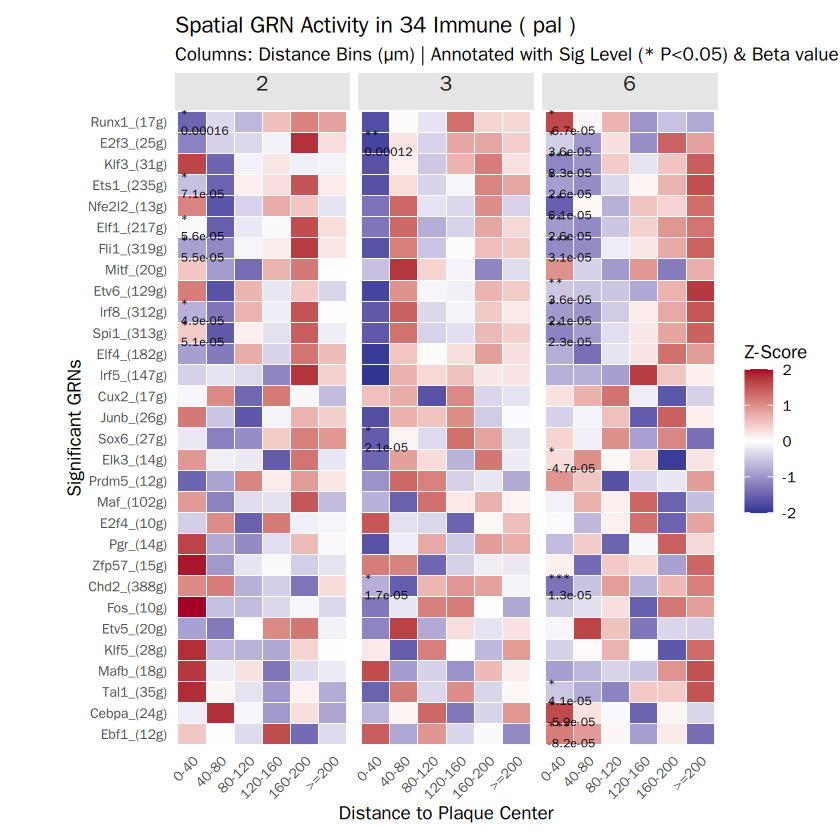

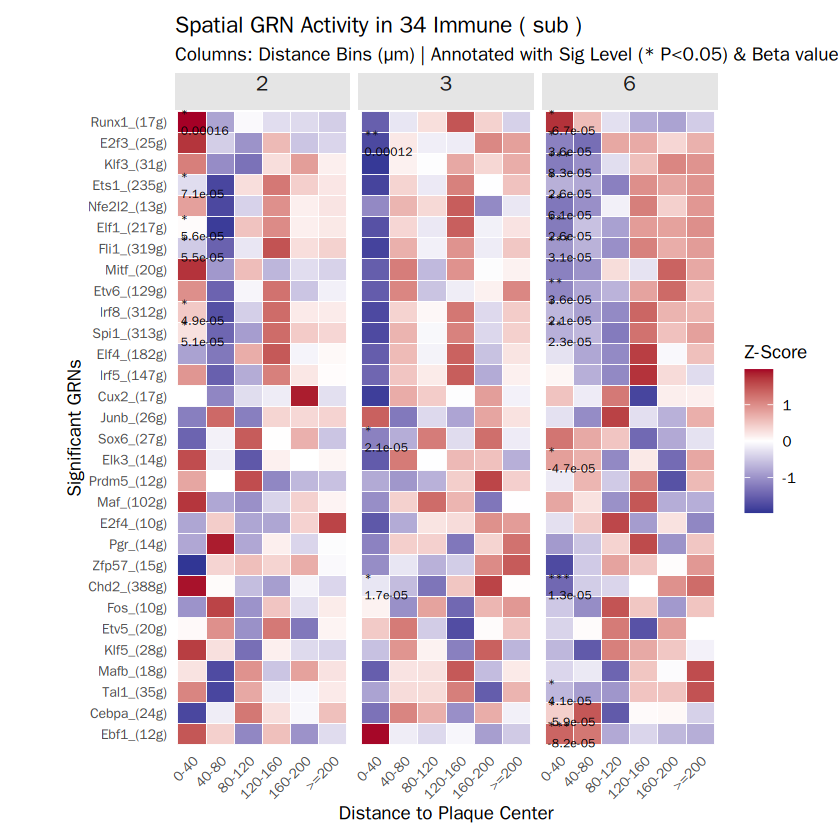

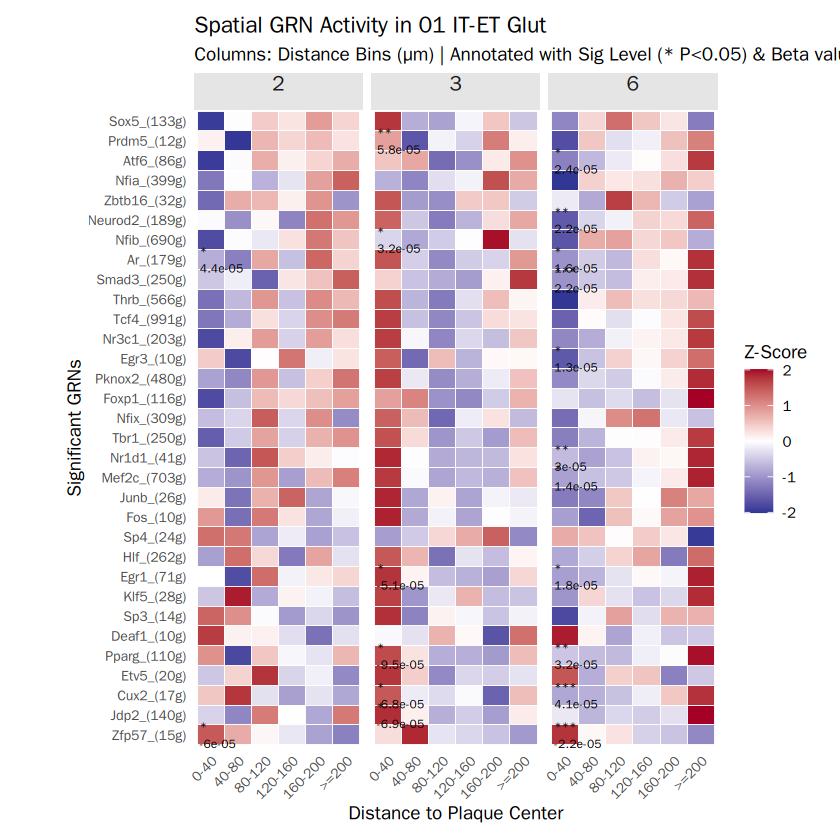

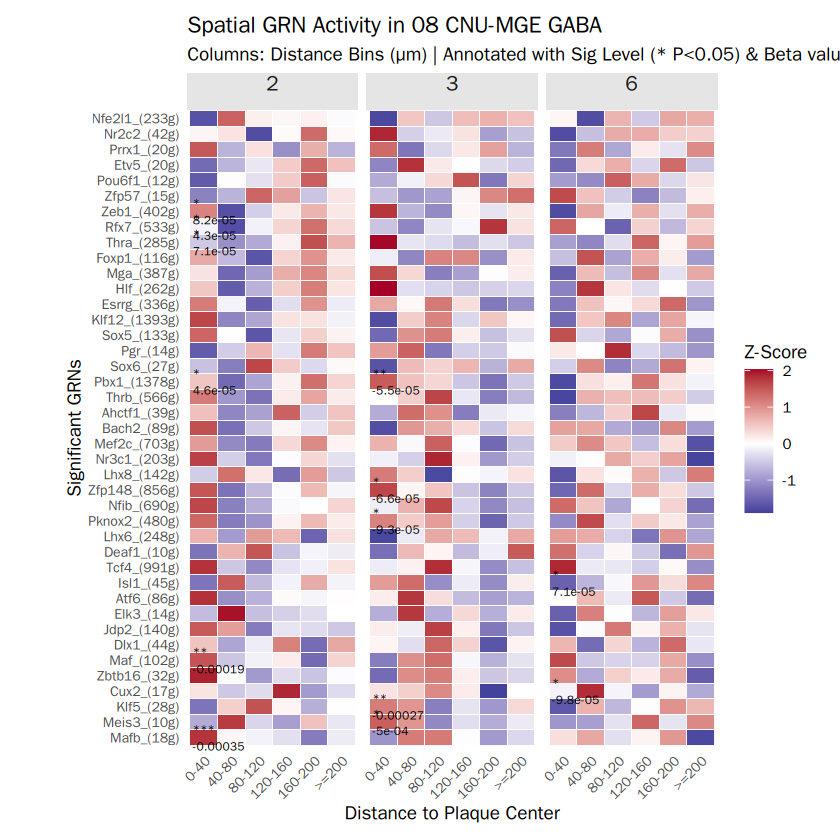

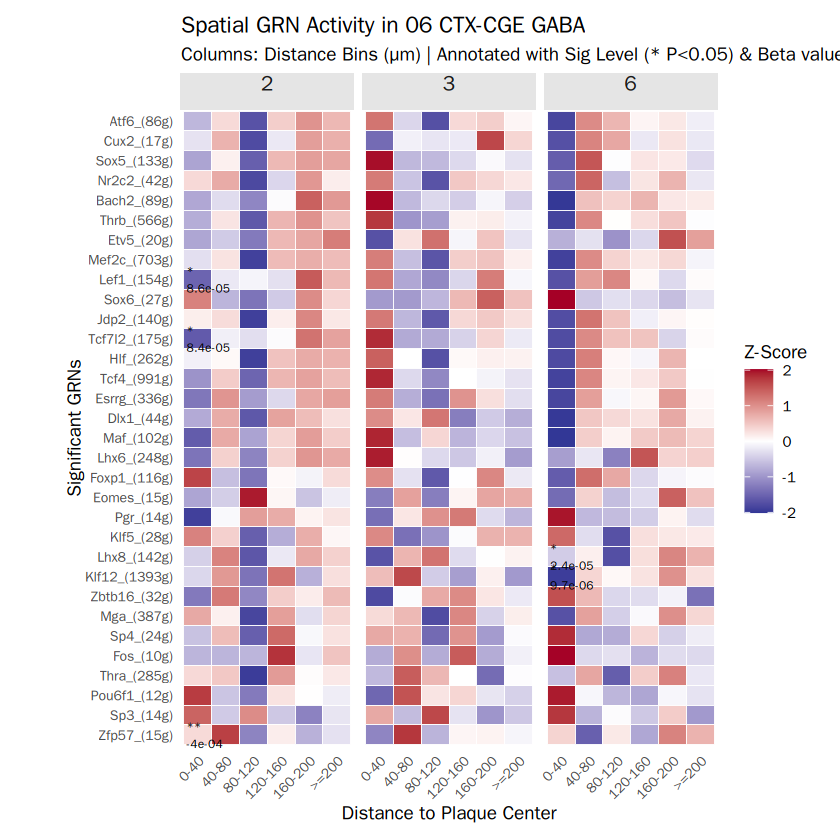

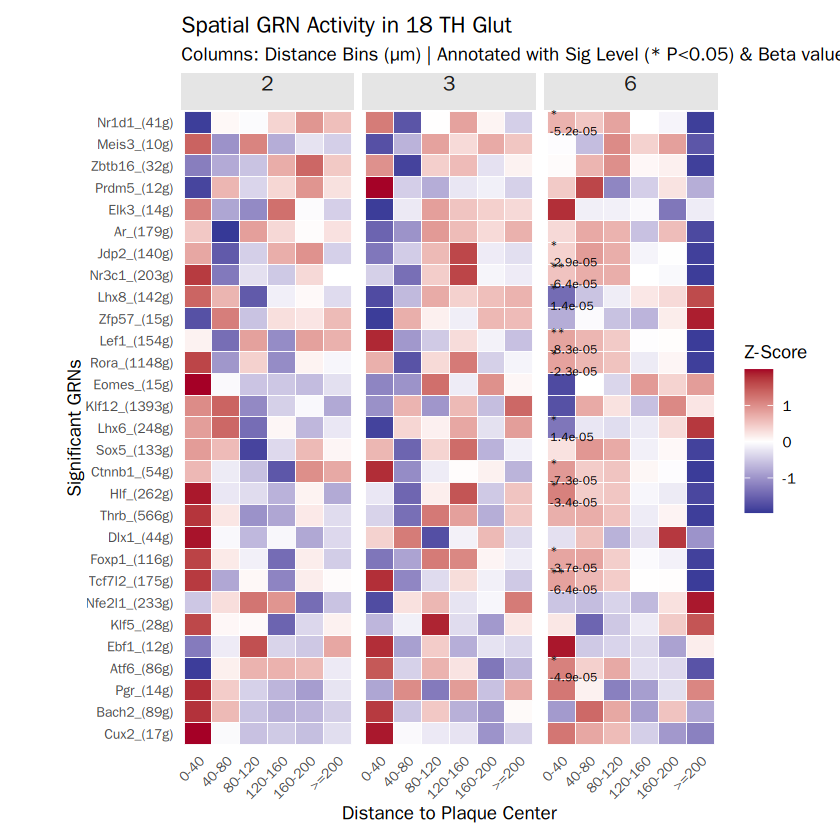

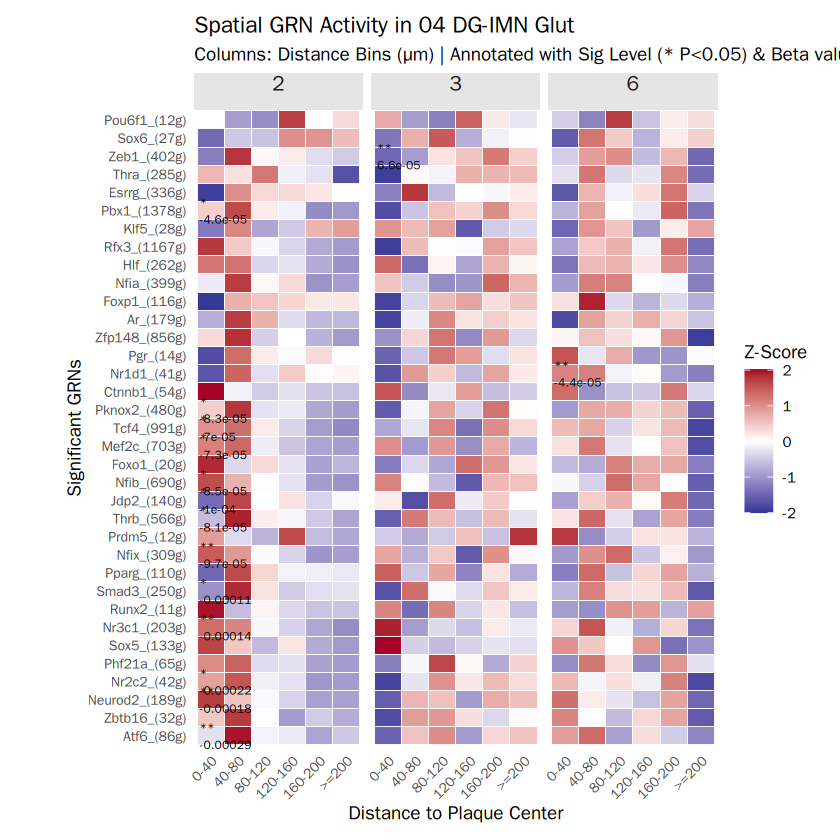

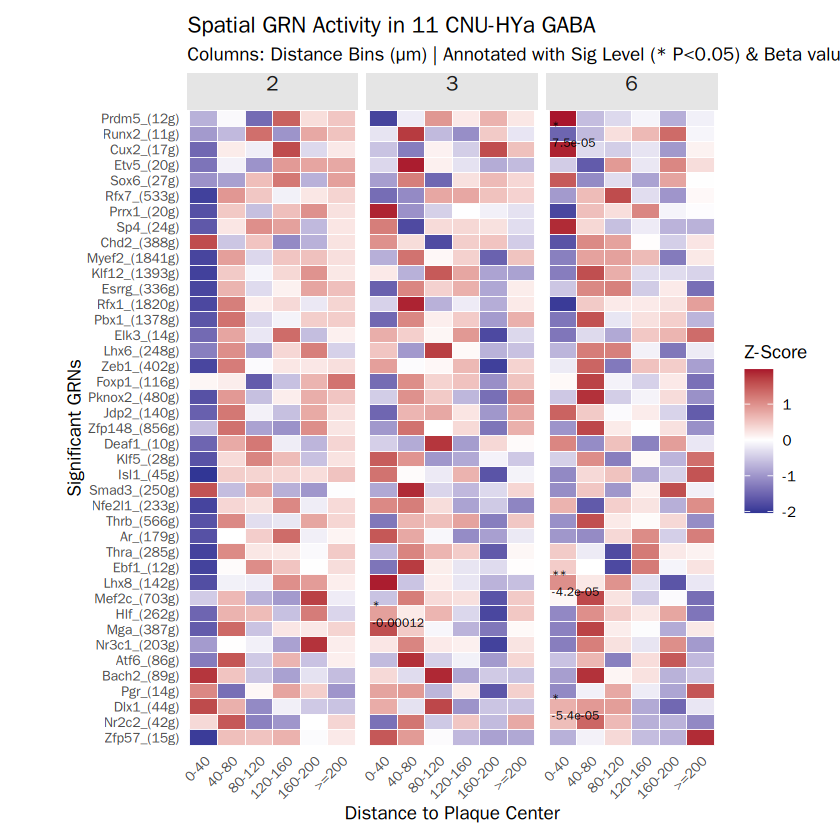

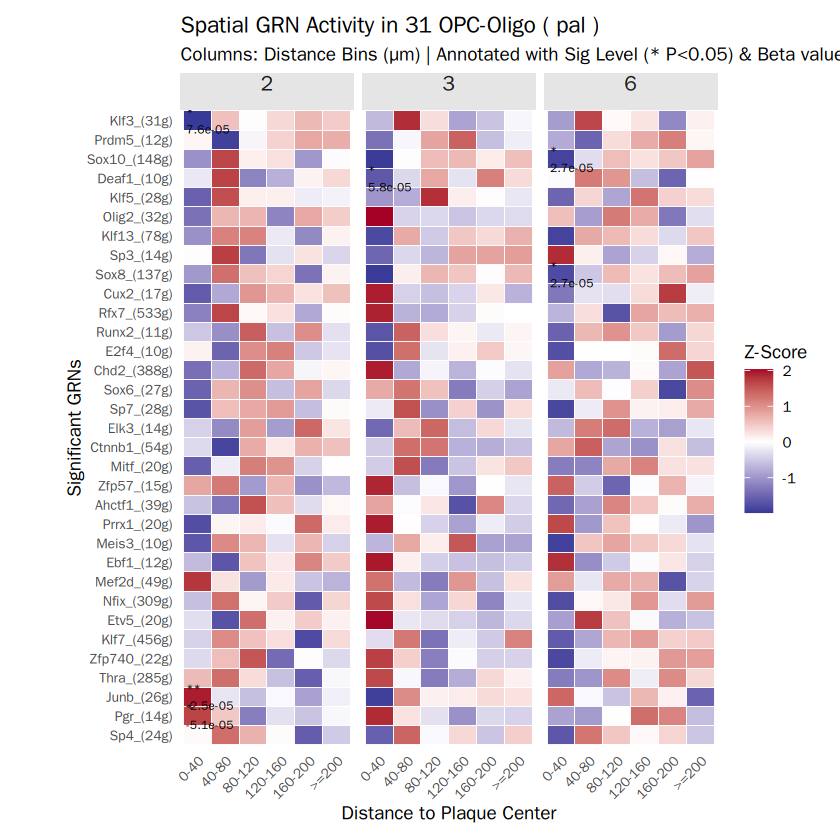

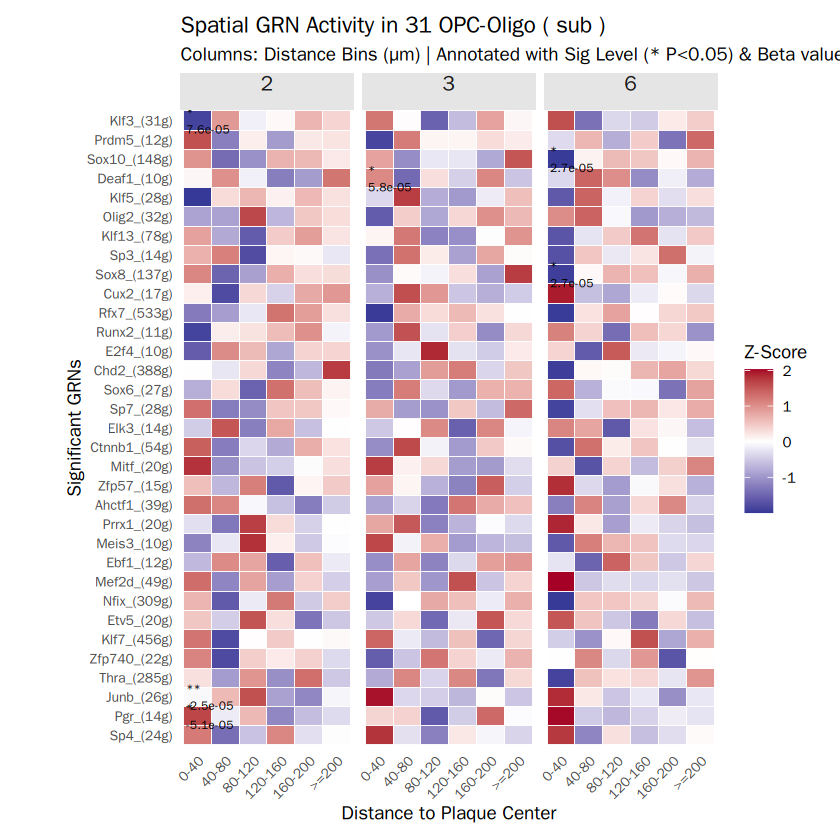

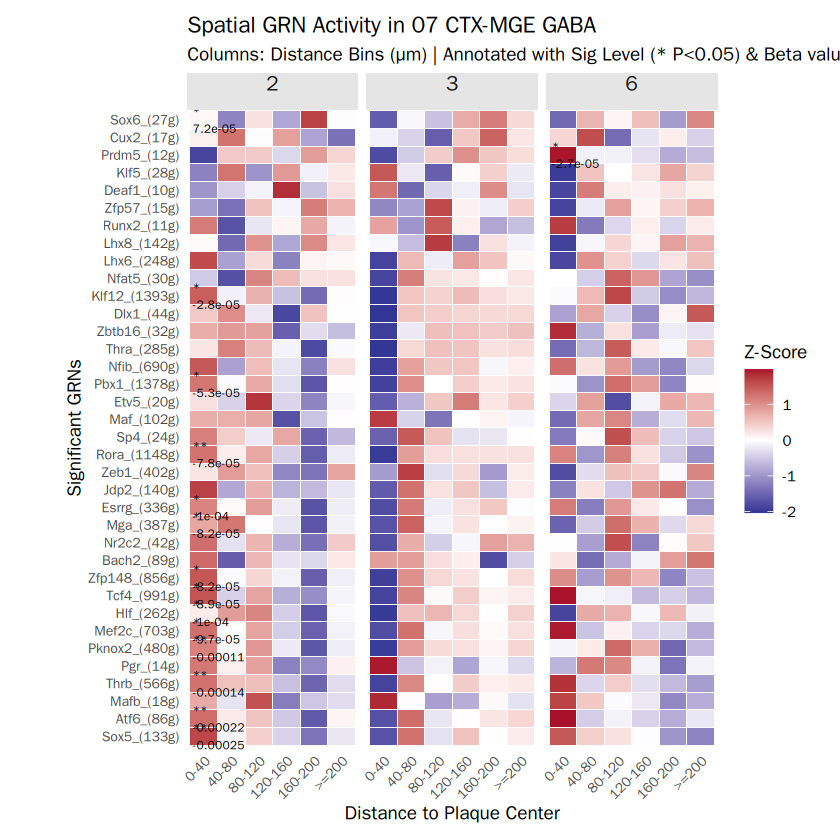

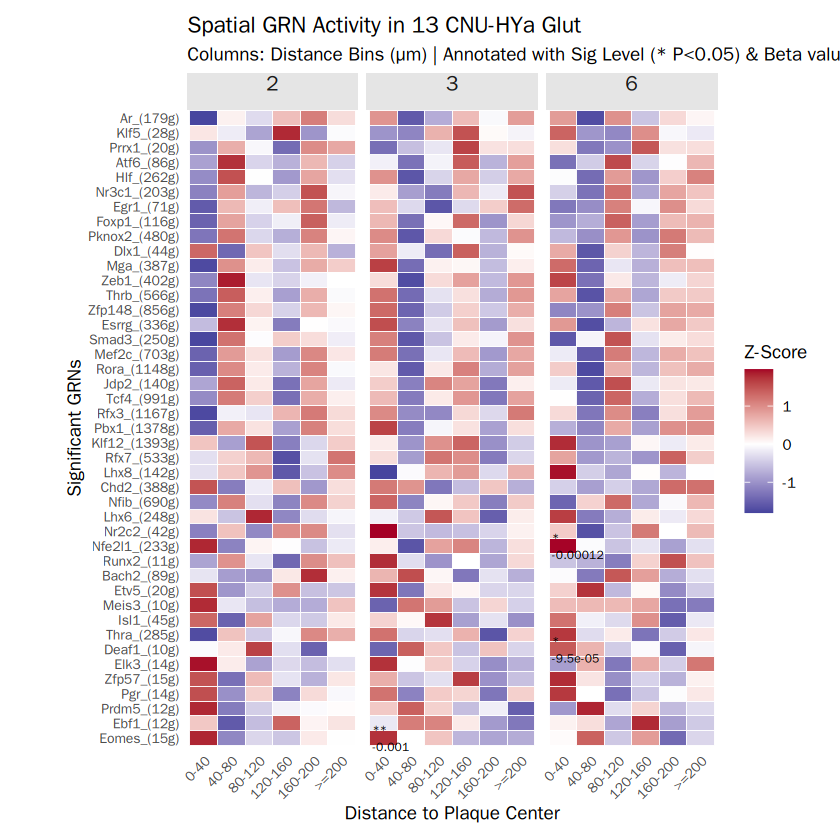

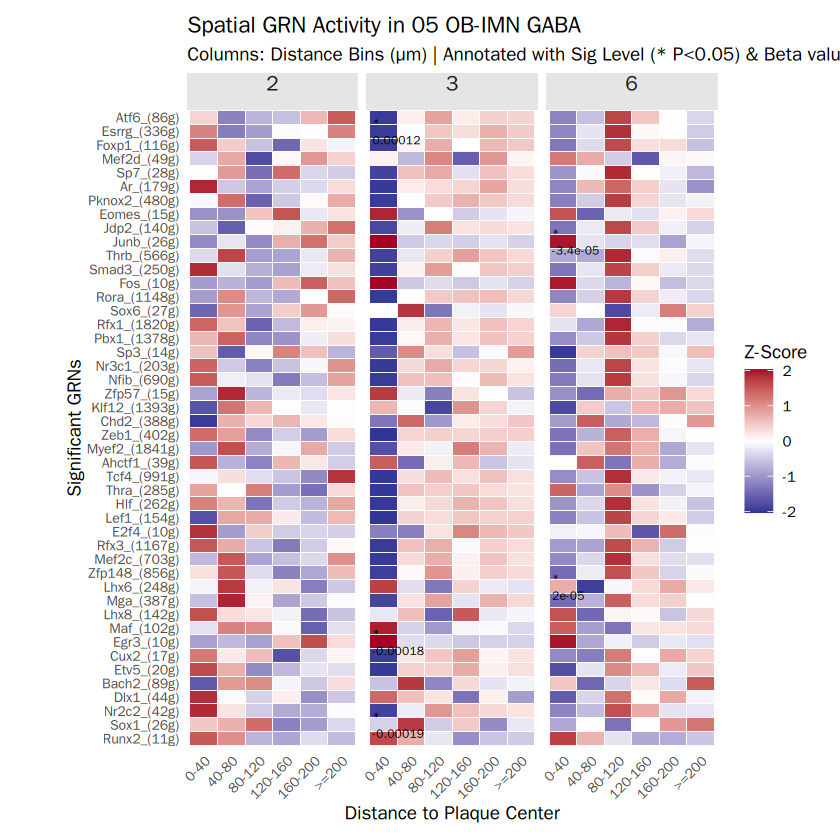

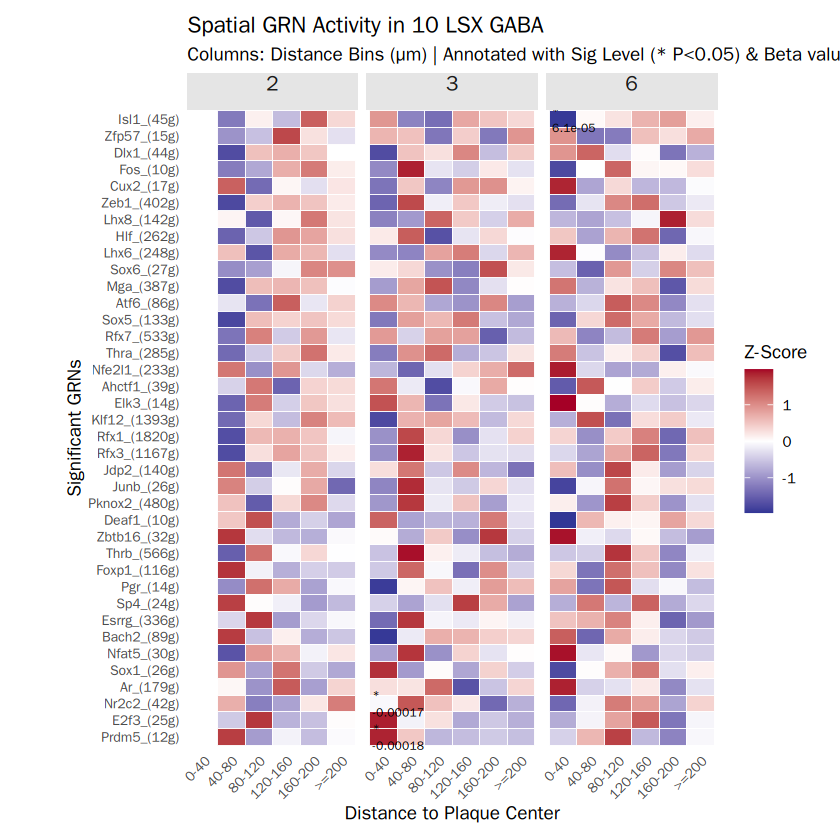

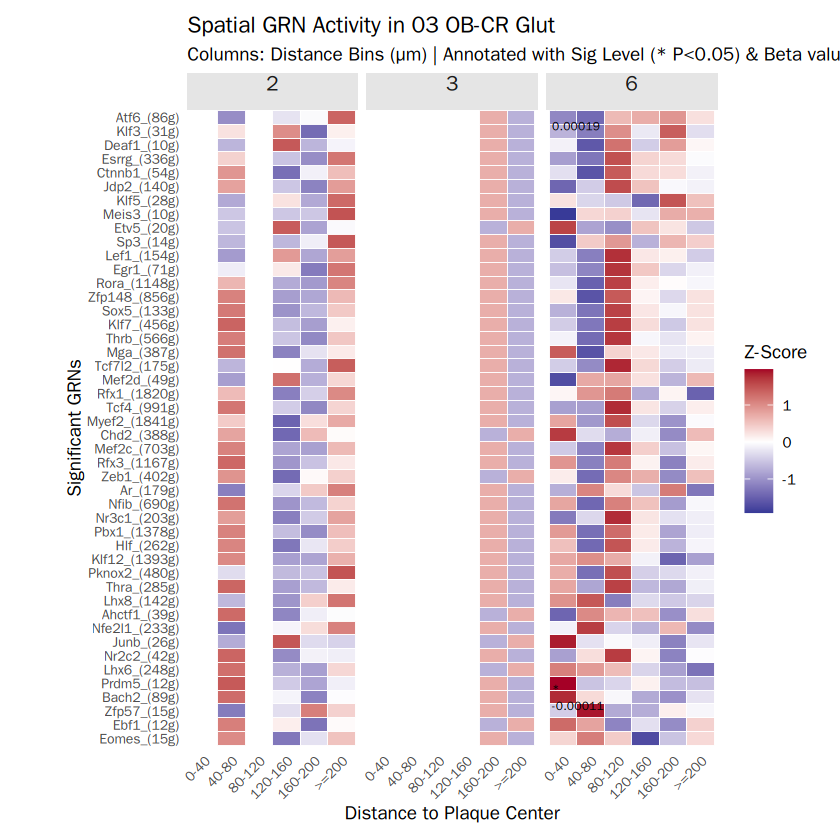

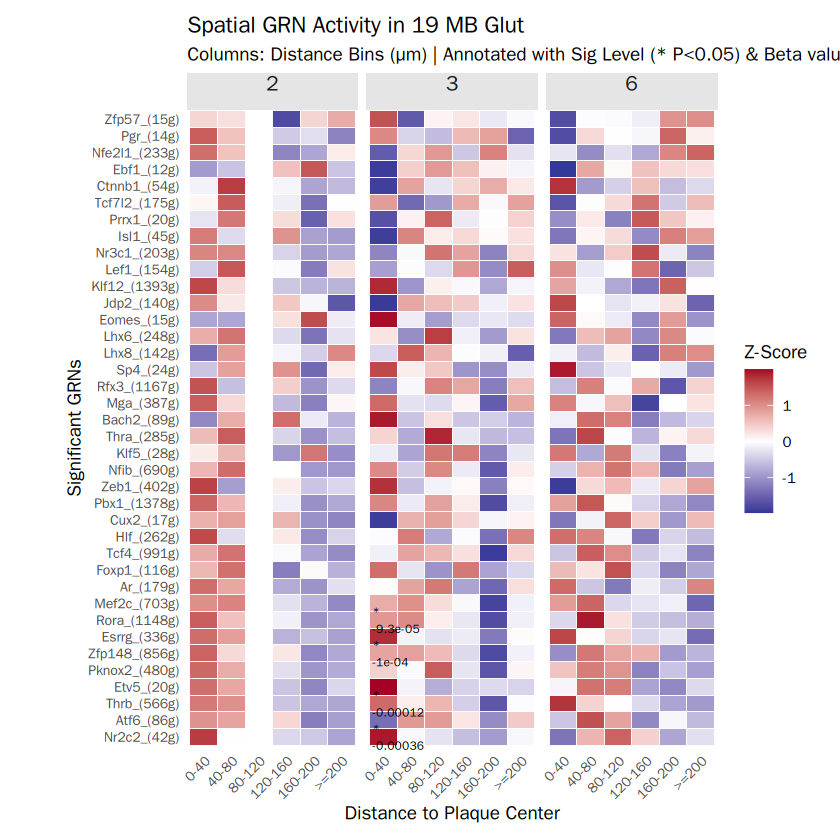

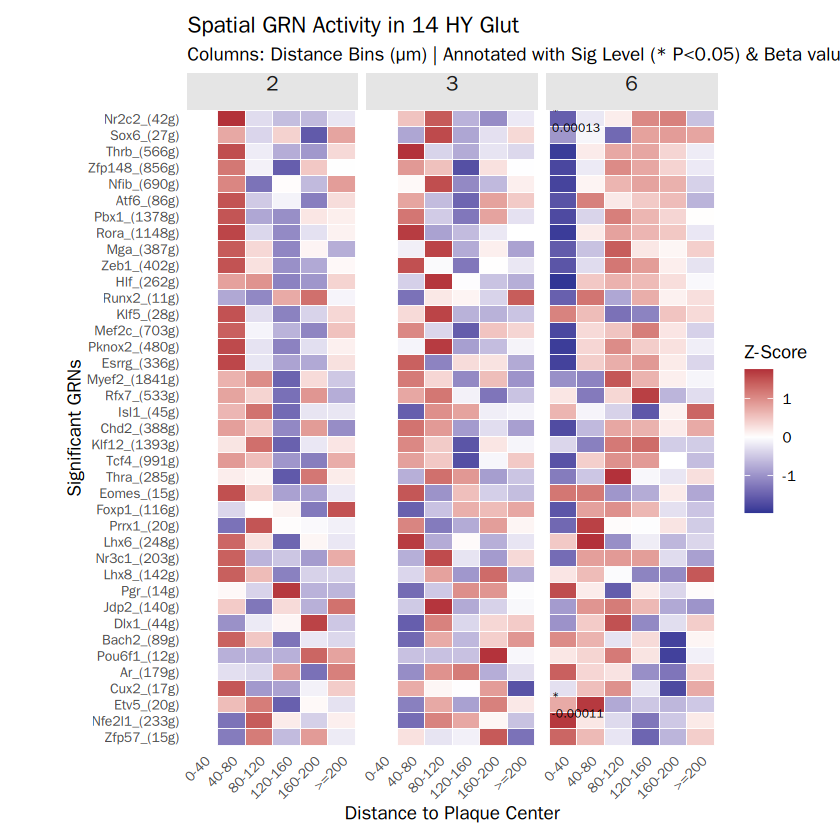

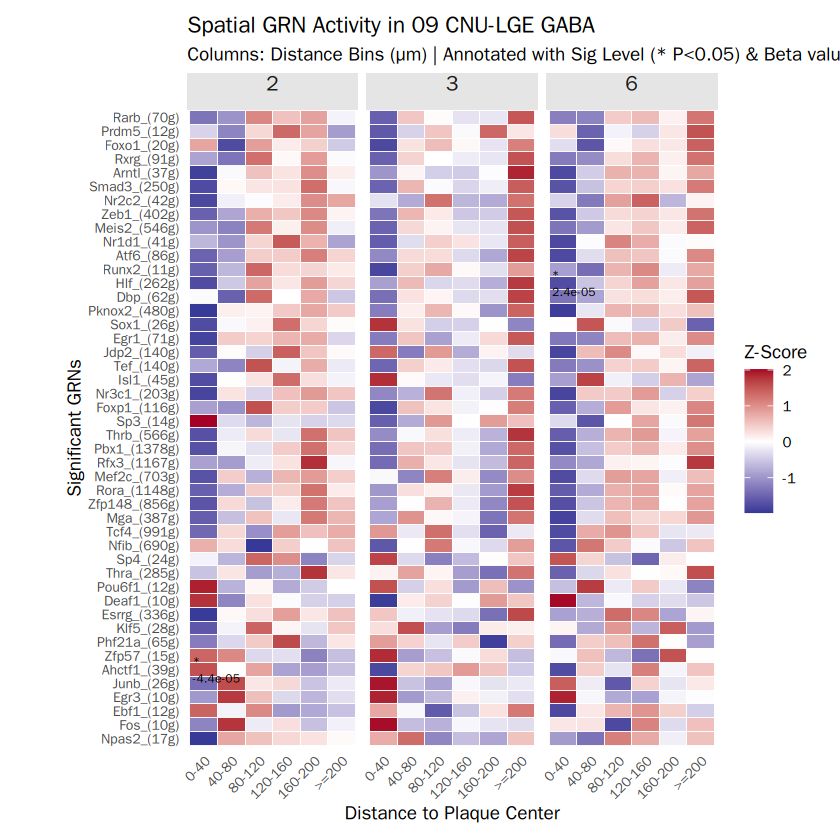

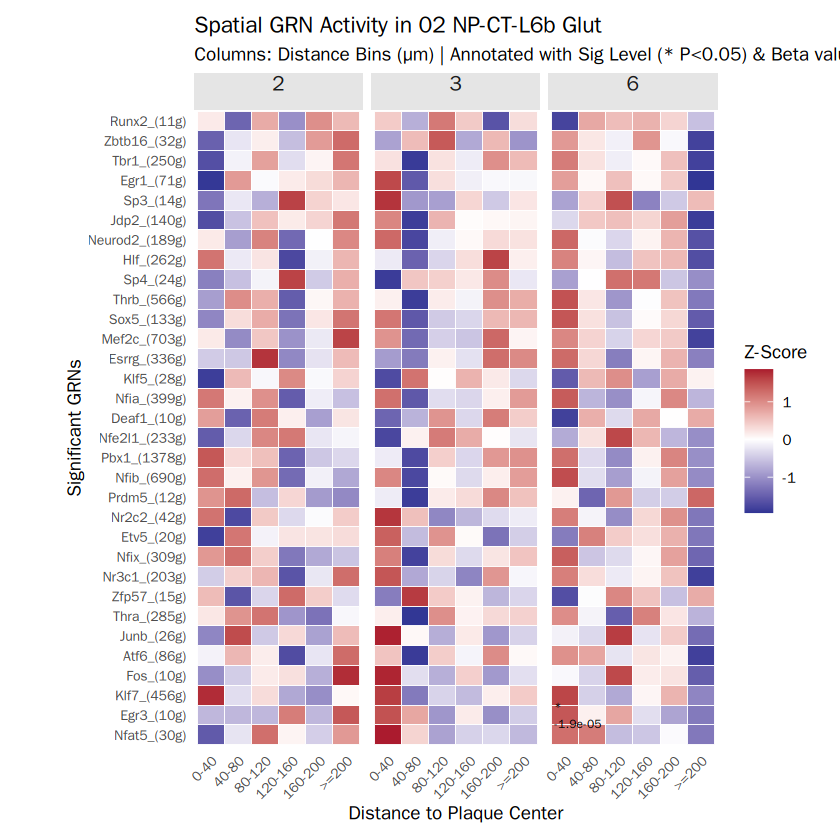

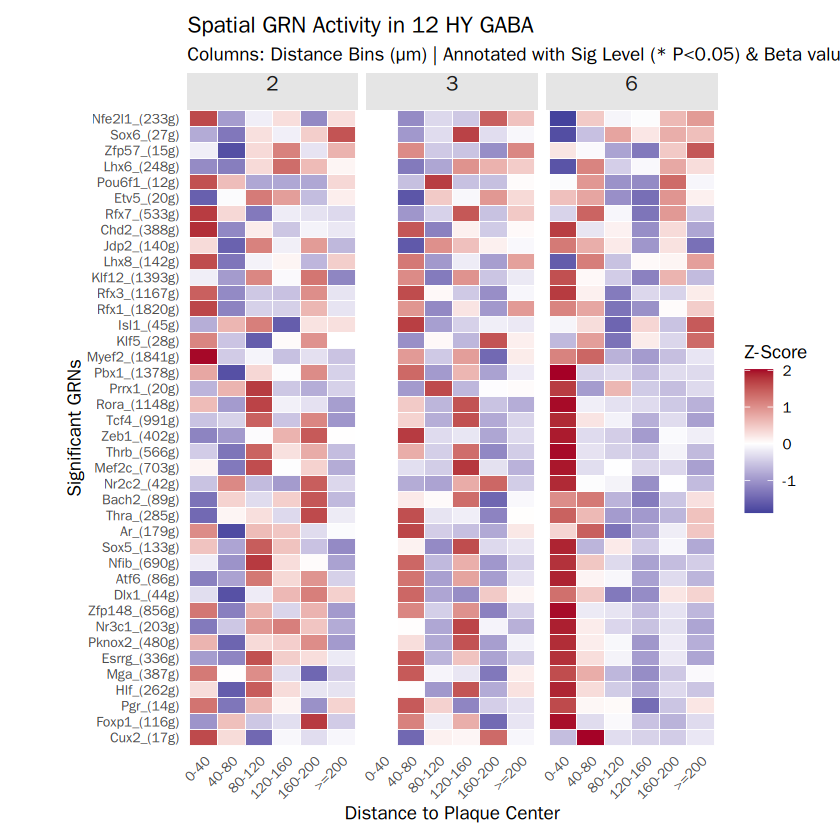

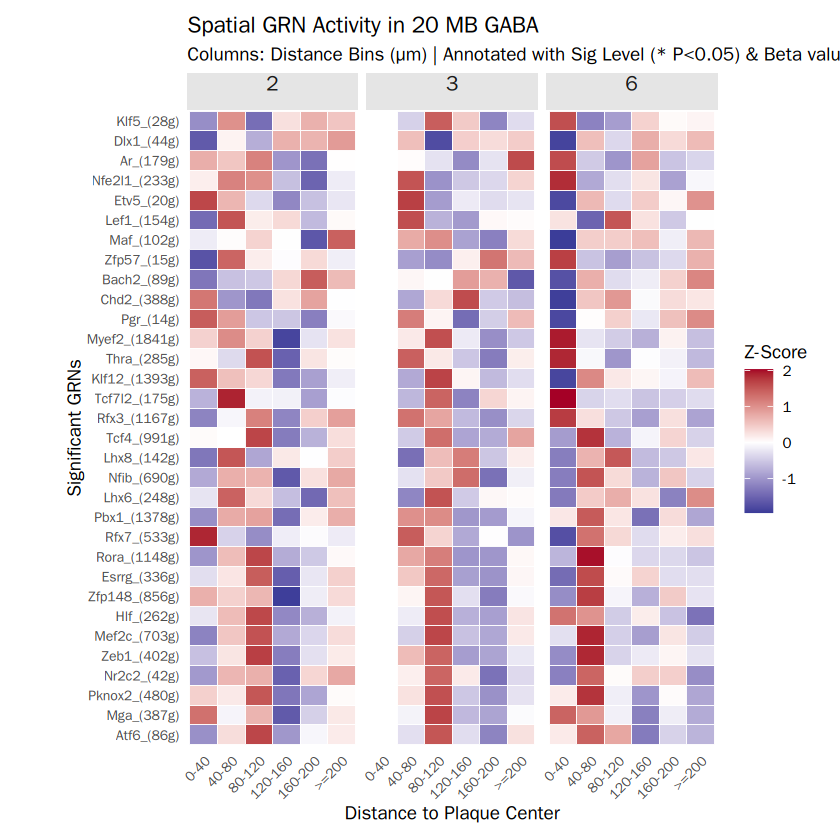

In [185]:
library(dplyr)
library(tidyr)
library(ggplot2)

# ==========================================
# 1. 基础设置与数据准备
# ==========================================
# 获取所有细胞类型
cell_types <- unique(grn_stats_df$CellType)

# 设定距离分箱的边界，将最后一个边界设为 Inf (无穷大)
dist_breaks <- c(seq(0, 200, by = 40), Inf)

# 自动生成美观的区间标签: "0-20", "20-40" ... "180-200", ">=200"
bin_labels <- c(paste0(seq(0, 160, by = 40), "-", seq(40, 200, by = 40)), ">=200")

# 创建一个专门保存图的列表
heatmap_list <- list()

print("开始生成分月龄空间热图 (带Beta值标注)...")

# ==========================================
# 2. 遍历细胞类型并绘图 (含脑区分面逻辑)
# ==========================================
for (ctype in cell_types) {
  
  # a. 找出该细胞类型下，至少在某一个月龄中 Pval < 0.05 的 GRN
  ctype_stats <- grn_stats_df %>% filter(CellType == ctype)
  sig_grns <- ctype_stats  %>% pull(GRN) %>% unique() 
  
  # 如果该细胞类型没有显著的 GRN，则跳过
  if (length(sig_grns) == 0) {
    message(paste("跳过", ctype, ": 没有显著相关的 GRN。"))
    next
  }
  
  # 【核心修改 1】：判断是否为胶质细胞 (名称中不包含 Glut 和 Gaba，忽略大小写)
  is_glial <- !grepl("Glut|Gaba", ctype, ignore.case = TRUE)
  
  # 【核心修改 2】：提取需要遍历的脑区
  if (is_glial) {
    # 如果是胶质细胞，去 spatial 表里抓取该细胞分布的所有脑区
    regions_to_plot <- spatial %>% 
      filter(class_id_label == ctype) %>% 
      pull(brain) %>% 
      unique() %>% 
      na.omit()
  } else {
    # 神经元等则默认合并绘制，标记为 "All"
    regions_to_plot <- c("All")
  }
  
  # 【核心修改 3】：嵌套循环，根据 regions_to_plot 绘制单张或多张图
  for (reg in regions_to_plot) {
    
    # b. 从 spatial 数据中提取该细胞类型的数据，并按需过滤脑区
    plot_data <- spatial %>% filter(class_id_label == ctype)
    
    if (reg != "All") {
      plot_data <- plot_data %>% filter(brain == reg)
    }
    
    # 防御性检查：如果该脑区内没有该细胞数据，直接跳过
    if (nrow(plot_data) == 0) {
      message(paste("跳过", ctype, "在脑区", reg, "的绘图：数据为空。"))
      next
    }
    
    plot_data <- plot_data %>%
      select(month, min_center_dist, all_of(sig_grns)) %>%
      mutate(Dist_Bin = cut(min_center_dist, 
                            breaks = dist_breaks, 
                            labels = bin_labels, 
                            include.lowest = TRUE)) %>%
      drop_na(Dist_Bin) 
    
    # c. 数据宽转长，并计算每个月龄、每个距离箱子的平均活性
    plot_data_long <- plot_data %>%
      pivot_longer(cols = all_of(sig_grns), names_to = "GRN", values_to = "Activity") %>%
      group_by(month, Dist_Bin, GRN) %>%
      summarise(Mean_Activity = mean(Activity, na.rm = TRUE), .groups = 'drop')
    
    # d. Z-score 标准化
    plot_data_long <- plot_data_long %>%
      group_by(GRN, month) %>%
      mutate(Z_Score = as.numeric(scale(Mean_Activity))) %>%
      ungroup()
    
    # e. 将统计显著性合并进来，并生成【星号 + Beta值】的复合标签
    plot_data_long <- plot_data_long %>%
      left_join(ctype_stats %>% select(Month, GRN, Pval, Beta_Distance), 
                by = c("month" = "Month", "GRN" = "GRN")) %>%
      mutate(
        Sig_Star = case_when(
          is.na(Pval) ~ "",
          Pval < 0.001 ~ "***",
          Pval < 0.01  ~ "**",
          Pval < 0.05  ~ "*",
          TRUE         ~ ""
        ),
        Label_Text = ifelse(Sig_Star != "", 
                            paste0(Sig_Star, "\n", signif(Beta_Distance, 2)), 
                            "")
      )
    
    # f. 决定星号画在哪：画在第一个 levels ("0-20") 上
    first_bin <- levels(plot_data_long$Dist_Bin)[1]
    annotation_data <- plot_data_long %>% filter(Dist_Bin == first_bin)
    
    # 按照总体 Beta_Distance 给 GRN 排序
    grn_order <- ctype_stats %>%
      group_by(GRN) %>%
      summarise(mean_beta = mean(Beta_Distance, na.rm = TRUE)) %>%
      arrange(mean_beta) %>%
      pull(GRN)
    
    plot_data_long$GRN <- factor(plot_data_long$GRN, levels = grn_order)
    annotation_data$GRN <- factor(annotation_data$GRN, levels = grn_order)
    
    # ==========================================
    # 3. 使用 ggplot2 绘制分面热图
    # ==========================================
    # 动态生成标题和列表命名
    plot_title <- ifelse(reg == "All", 
                         paste("Spatial GRN Activity in", ctype), 
                         paste("Spatial GRN Activity in", ctype, "(", reg, ")"))
    
    list_name <- ifelse(reg == "All", 
                        ctype, 
                        paste(ctype, reg, sep = "_"))
    
    p <- ggplot(plot_data_long, aes(x = Dist_Bin, y = GRN, fill = Z_Score)) +
      geom_tile(color = "white", linewidth = 0.2) +  
      
      geom_text(data = annotation_data, aes(label = Label_Text), 
                color = "black", size = 2.5, fontface = "bold", 
                hjust = 0, nudge_x = -0.4) + 
      
      scale_fill_gradient2(low = "#313695", mid = "white", high = "#a50026", midpoint = 0) +
      scale_y_discrete(labels = function(x) gsub("_direct_\\+/\\+", "", x)) +
      
      facet_wrap(~ month, ncol = length(unique(plot_data_long$month))) + 
      labs(
        title = plot_title,
        subtitle = "Columns: Distance Bins (µm) | Annotated with Sig Level (* P<0.05) & Beta value",
        x = "Distance to Plaque Center",
        y = "Significant GRNs",
        fill = "Z-Score"
      ) +
      theme_minimal() +
      coord_cartesian(clip = "off") + 
      theme(
        axis.text.x = element_text(angle = 45, hjust = 1, size = 8),
        axis.text.y = element_text(size = 8),
        panel.grid = element_blank(), 
        strip.text = element_text(size = 12, face = "bold", margin = margin(b = 10)), 
        strip.background = element_rect(fill = "grey90", color = NA),
        plot.margin = margin(t = 10, r = 10, b = 10, l = 40, unit = "pt") 
      )
    
    # 保存进 list 并打印
    heatmap_list[[list_name]] <- p
    print(p) 
  }
}

[1] "开始生成 34 Immune 中 Ebf1 的斑块距离折线图..."


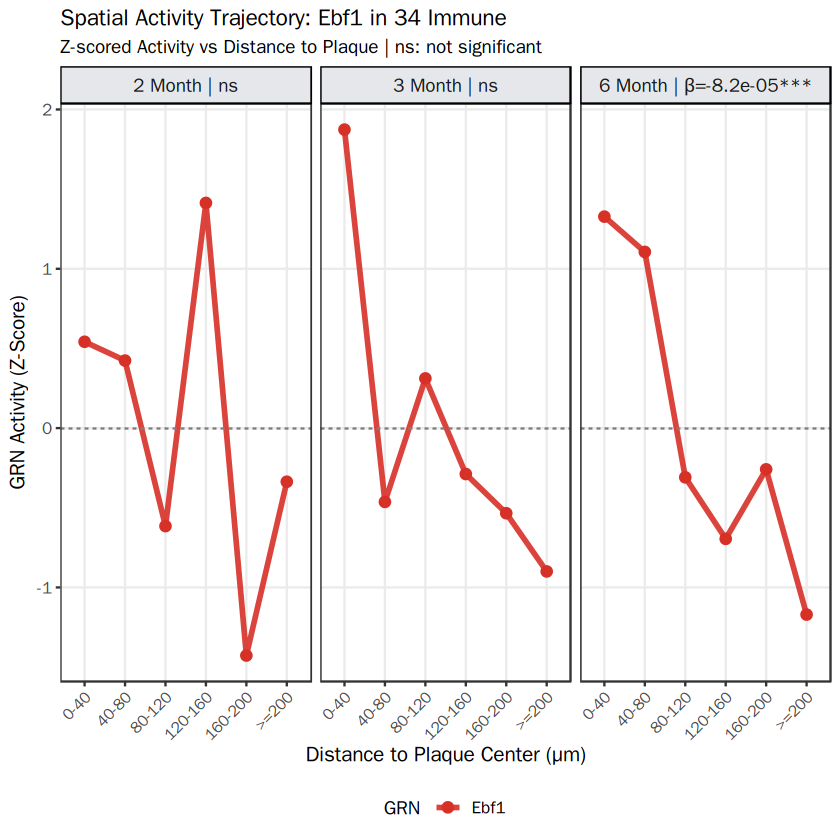

In [150]:
library(dplyr)
library(tidyr)
library(ggplot2)

# ==========================================
# 1. 设定目标细胞类型、目标 TF 和数据准备
# ==========================================
target_ctype <- "34 Immune" 
target_tf <- "Ebf1"

print(paste("开始生成", target_ctype, "中", target_tf, "的斑块距离折线图..."))

dist_breaks <- c(seq(0, 200, by = 40), Inf)
bin_labels <- c(paste0(seq(0, 160, by = 40), "-", seq(40, 200, by = 40)), ">=200")

# a. 提取 Immune 细胞的统计结果
ctype_stats <- grn_stats_df %>% filter(CellType == target_ctype)
sig_grns <- ctype_stats %>% pull(GRN) %>% unique()

# 只保留 Spi1
sig_grns <- sig_grns[grepl(paste0("^", target_tf, "_"), sig_grns)]

if (length(sig_grns) == 0) {
  stop(paste("错误：在", target_ctype, "中没有找到名为", target_tf, "的 GRN。"))
}

# ==========================================
# 2. 数据处理与 Z-score 计算
# ==========================================
plot_data <- spatial %>%
  filter(class_id_label == target_ctype) %>%
  select(month, min_center_dist, all_of(sig_grns)) %>%
  mutate(Dist_Bin = cut(min_center_dist, 
                        breaks = dist_breaks, 
                        labels = bin_labels, 
                        include.lowest = TRUE)) %>%
  drop_na(Dist_Bin) 

# 宽转长，计算均值
plot_data_long <- plot_data %>%
  pivot_longer(cols = all_of(sig_grns), names_to = "GRN", values_to = "Activity") %>%
  group_by(month, Dist_Bin, GRN) %>%
  summarise(Mean_Activity = mean(Activity, na.rm = TRUE), .groups = 'drop')

# 计算 Z-score
plot_data_long <- plot_data_long %>%
  group_by(GRN, month) %>%
  mutate(Z_Score = as.numeric(scale(Mean_Activity))) %>%
  ungroup()

# ==========================================
# 3. 将统计信息整合入【分面标题(Facet_Label)】中
# ==========================================
plot_data_long <- plot_data_long %>%
  left_join(ctype_stats %>% select(Month, GRN, Pval, Beta_Distance), 
            by = c("month" = "Month", "GRN" = "GRN")) %>%
  mutate(
    Sig_Star = case_when(
      is.na(Pval) ~ "",
      Pval < 0.001 ~ "***",
      Pval < 0.01  ~ "**",
      Pval < 0.05  ~ "*",
      TRUE         ~ ""
    ),
    Clean_GRN = gsub("_direct_\\+/\\+.*$", "", GRN),
    
    # 【核心修复】：为每个分面生成独立的标题，例如 "Month 4 | β=-0.015**" 或 "Month 2 | ns"
    Facet_Label = ifelse(Sig_Star != "", 
                         paste0(month, " Month | β=", signif(Beta_Distance, 2), Sig_Star),
                         paste0(month, " Month | ns"))
  )

# ==========================================
# 4. 使用 ggplot2 绘制折线图
# ==========================================
# 这里 color 和 group 都绑定到 Clean_GRN (只有一个值 "Spi1")，所以只用 1 个颜色完美匹配
p_line <- ggplot(plot_data_long, aes(x = Dist_Bin, y = Z_Score, color = Clean_GRN, group = Clean_GRN)) +
  geom_line(linewidth = 1.2, alpha = 0.9) +
  geom_point(size = 2.5, alpha = 1) +
  
  # 【核心修复】：按带有统计数据的 Facet_Label 分面
  facet_wrap(~ Facet_Label, ncol = length(unique(plot_data_long$month))) +
  
  geom_hline(yintercept = 0, linetype = "dashed", color = "grey50") +
  
  # 因为此时 Clean_GRN 只有 "Spi1" 这1个固定值，所以这里提供 1 个颜色完全合法
  scale_color_manual(values = "#d73027") +
  
  labs(
    title = paste("Spatial Activity Trajectory:", target_tf, "in", target_ctype),
    subtitle = "Z-scored Activity vs Distance to Plaque | ns: not significant",
    x = "Distance to Plaque Center (µm)",
    y = "GRN Activity (Z-Score)",
    color = "GRN" # 图例标题
  ) +
  
  theme_bw() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 9),
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12, face = "bold"),
    
    # 让分面的灰色标题栏更明显，因为现在上面记录了核心的统计结果
    strip.text = element_text(size = 11, face = "bold", margin = margin(b = 6, t = 6)),
    strip.background = element_rect(fill = "#E5E7EB", color = "black"),
    
    legend.position = "bottom", 
    legend.text = element_text(size = 10, face = "bold"),
    panel.grid.minor = element_blank() 
  )

print(p_line)